# 🛟 What every NeuroGolf write-up assumes you know

*By [Georgy Mamarin](https://www.kaggle.com/georgymamarin)*

[NeuroGolf 2026](https://www.kaggle.com/competitions/neurogolf-2026) is over and the winners' write-ups are landing — read them. The game, in one line: 400 ARC-style grid puzzles, each solved by one ONNX file, scored `25 − ln(params + memory)` per task, floored at 1 — the smallest network wins. And all of the write-ups assume you already know the plumbing: what the metric bills, why the scoring server rejects files your laptop runs fine, which "banned" ops are real. This kit is that missing intro, built during the competition after one bad file cost me a full submission. Inside: an exact local scorer, a pre-submit validator, a myth-bust of the op ban list — and the file that is invalid ONNX yet passes `onnx.checker`, shape-inference, the pinned runtime, and this kit's own `diagnose()` gauntlet — one static check is all that stops it. It ends with [what the winners did](#winners) and which part of the kit each idea lands on.

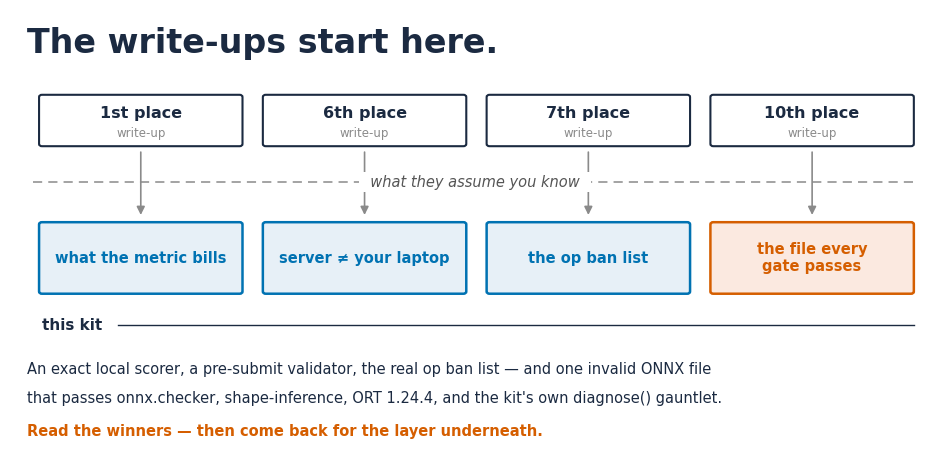

In [1]:
import warnings; warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# Okabe-Ito: readable without colour vision; every mark also labelled in words.
BLUE, VERM, INK, GREY = "#0072B2", "#D55E00", "#1b2a41", "#8a8a8a"

fig, ax = plt.subplots(figsize=(9.6, 4.6))
ax.set_xlim(0, 16); ax.set_ylim(0, 9.6); ax.axis("off")

ax.text(0.3, 8.85, "The write-ups start here.", fontsize=24, fontweight="bold", color=INK, va="center")

# --- top layer: the winners' write-ups -------------------------------------
tops = ["1st place", "6th place", "7th place", "10th place"]
tw, th, ty = 3.4, 1.05, 6.6
for i, t in enumerate(tops):
    x = 0.55 + i * (tw + 0.45)
    ax.add_patch(FancyBboxPatch((x, ty), tw, th, boxstyle="round,pad=0.05",
                                fc="white", ec=INK, lw=1.5))
    ax.text(x + tw/2, ty + th/2 + 0.16, t, ha="center", va="center",
            fontsize=11.5, fontweight="bold", color=INK)
    ax.text(x + tw/2, ty + th/2 - 0.28, "write-up", ha="center", va="center",
            fontsize=8.5, color=GREY)

# --- the dividing line: what they assume ------------------------------------
ax.plot([0.4, 15.6], [5.75, 5.75], color=GREY, lw=1.1, ls=(0, (6, 4)))
ax.text(8.0, 5.75, "  what they assume you know  ", ha="center", va="center",
        fontsize=10.5, style="italic", color="#555",
        bbox=dict(fc="white", ec="none", pad=1.5))

for i in range(4):
    cx = 0.55 + i * (tw + 0.45) + tw/2
    ax.add_patch(FancyArrowPatch((cx, ty - 0.12), (cx, 4.95),
                                 arrowstyle="-|>", mutation_scale=12, color=GREY, lw=1.2))

# --- bottom layer: the kit --------------------------------------------------
bots = [("what the metric bills", BLUE), ("server ≠ your laptop", BLUE),
        ("the op ban list", BLUE), ("the file every\ngate passes", VERM)]
bw, bh, by = 3.4, 1.5, 3.3
for i, (t, col) in enumerate(bots):
    x = 0.55 + i * (bw + 0.45)
    fc = "#e7f0f7" if col == BLUE else "#fbe9e0"
    ax.add_patch(FancyBboxPatch((x, by), bw, bh, boxstyle="round,pad=0.05",
                                fc=fc, ec=col, lw=1.8))
    ax.text(x + bw/2, by + bh/2, t, ha="center", va="center",
            fontsize=10.5, fontweight="bold", color=col)

ax.text(0.55, 2.55, "this kit", fontsize=11, fontweight="bold", color=INK, va="center")
ax.plot([1.85, 15.55], [2.55, 2.55], color=INK, lw=1.0)

ax.text(0.3, 1.55, "An exact local scorer, a pre-submit validator, the real op ban list — and one invalid ONNX file",
        fontsize=10.5, color=INK, va="center")
ax.text(0.3, 0.9, "that passes onnx.checker, shape-inference, ORT 1.24.4, and the kit's own diagnose() gauntlet.",
        fontsize=10.5, color=INK, va="center")
ax.text(0.3, 0.18, "Read the winners — then come back for the layer underneath.",
        fontsize=10.5, color=VERM, fontweight="bold", va="center")

fig.tight_layout()
plt.show()

Everything is self-contained: **Run All** works with no data attached (it builds tiny demo models to show each tool). It is the groundwork every entry needed — the winners' write-ups now reveal the architectures; this kit is the layer underneath. Unlike static checkers (shape-inference + a hand-listed op blacklist), this opens a **real** ONNX Runtime 1.24.4 session on a real grid, which is the reliable way to catch the `ERROR`s that zero your submission. It runs in about a minute on a Kaggle CPU session, and takes about ten to read.

**What you will learn**

1. Why your local `onnxruntime` lies to you about cost and `ERROR`s — and how to match the server.
2. The exact cost formula (`params + memory`), reproduced node-for-node, so you stop trusting `onnx-tool`.
3. How to catch the one bad file *before* it zeroes your whole submission — including the invalid `Conv` bias that `onnx.checker`, shape-inference and a local run all wave through.
4. Which "forbidden" ops are folklore and which are real (spoiler: `TopK` runs fine).
5. Where the cost hides — which of the 400 tasks hold most of the recoverable points, so you know where surgery pays.
6. Why a file that runs perfectly can still contribute zero — and the fresh-seed check that catches it.

<p style="background-color:#fff4e6;padding:16px;color:#111;font-size:15px;border:2px solid #ffd8a8;border-radius:6px">
<strong>The trap:</strong> a single unscorable file makes your <em>entire</em> submission.zip score <strong>zero</strong>. And your local <code>onnxruntime</code> is almost certainly newer than the server's <code>1.24.4</code>, so a file that passes locally can still <code>ERROR</code> on the grader. This kit closes both gaps.
</p>

### Contents
1. [Why I built this — match the server runtime](#part0)
2. [Exact local cost scorer](#part1) — `params + memory`, the real formula
3. [Pre-submit validator](#part2) — real ORT session, catches `ERROR` before you submit
4. [Op myth-busting](#part3) — `TopK` works; probe, don't guess
5. [Where the cost hides](#part4) — a mini-EDA of the worklist
6. [Use it on your own submission](#use-it) — run the validator over your own bundle
7. [The silent zero](#silent-zero) — the one failure the validator can't catch
8. [What didn't pay off](#dead-ends) — dead ends, priced with the same scorer
9. [Takeaways](#takeaways)
10. [What the winners did](#winners) — their write-ups, mapped to the kit
11. [What to read next](#reading)

<a id="part0"></a>
## Why I built this — match the server runtime

I lost a full submission to a single `ERROR`. One `TopK` node — fine on my local `onnxruntime`, rejected by the scoring server. The whole `submission.zip` scored nothing, and I burned a day finding which of 400 files was the culprit.

The scoring server runs a **specific, older ONNX Runtime**, applies a strict sanitizer, and one unscorable file zeroes everything. None of that is visible from a normal local run. So I rebuilt the scoring pipeline locally.

In [2]:
# The scoring server is pinned to an OLDER ONNX Runtime than you probably have locally.
# Match it. (On Kaggle this installs into the session; locally use a venv.)
import sys, subprocess
def _pip(*pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs],
                   check=False, capture_output=True)  # swallow pip dependency-conflict noise

# Pin to the scoring-server stack. Adjust if the host announces a new version.
_pip("onnx==1.21.0", "onnxruntime==1.24.4", "numpy==2.4.4")

# (numpy is pinned for fresh kernels/forks; this session imported it above, and its exact
#  version does not change the scorer's integer byte counts -- only onnx/onnxruntime must match.)
import onnx, onnxruntime as ort, numpy as np
print("onnx", onnx.__version__, "| onnxruntime", ort.__version__)

SERVER_ORT = "1.24.4"
if ort.__version__ != SERVER_ORT:
    print(f"\n  WARNING: you are on {ort.__version__}, the server scores on {SERVER_ORT}.")
    print("  Newer runtimes infer shapes / optimize differently -> your local cost AND ERROR set can both be wrong.")
else:
    print(f"\n  OK: matched the server runtime {SERVER_ORT}. Your local cost/ERROR checks now mirror the grader.")

# Working locally on an ARM64 Mac? The host reports the scorer is fine "provided that all Conv
# operations in submitted networks exhibit the proper length & bias values", but for local ARM64
# experiments he recommends ONNX Runtime 1.26.0 plus one session option:
#     options.add_session_config_entry("mlas.disable_kleidiai", "1")
# (Michael D. Moffitt, competition host, discussion 699840.) The structural checks in this kit are
# runtime-independent, so they stay exact either way.

onnx 1.21.0 | onnxruntime 1.24.4

  OK: matched the server runtime 1.24.4. Your local cost/ERROR checks now mirror the grader.


<a id="part1"></a>
## Part 1 — Exact local cost scorer

The objective is `score = max(1, 25 − ln(cost))` per task, and

> **cost = total parameters + total memory footprint (bytes).**

Two things people get wrong locally:

- **`onnx-tool`'s estimate is not the score.** The grader sums **every intermediate tensor's** memory as `max(static_shape_bytes, runtime_profile_bytes)`, with the graph's `input`/`output` tensors **free**.
- **Optimisation is OFF on the server** (`ORT_DISABLE_ALL`). It will *not* fold your constants or fuse anything, so every constant subgraph you leave in is paid for in memory.

Below is a standalone replica (no `neurogolf_utils` dependency) you can drop into your own pipeline. *(I verified it bit-for-bit against the official `neurogolf_utils.py`, which ships with the competition data — attach the competition and diff it yourself.)*

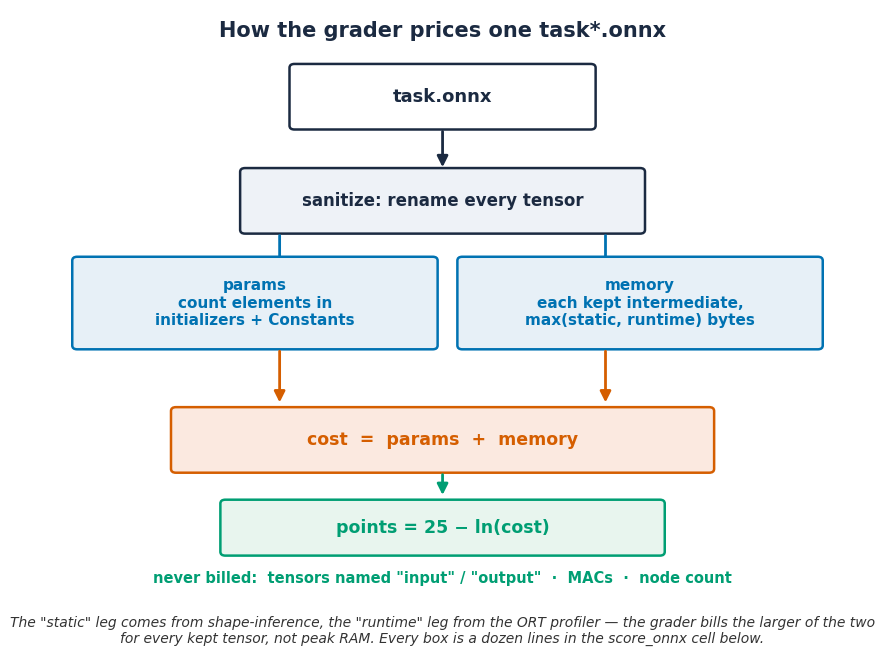

In [3]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

BLUE, VERM, GREEN, INK = "#0072B2", "#D55E00", "#009E73", "#1b2a41"

fig, ax = plt.subplots(figsize=(8.2, 6.2))
ax.set_xlim(0, 16); ax.set_ylim(-0.3, 15); ax.axis("off")

ax.text(8, 14.3, "How the grader prices one task*.onnx", ha="center",
        fontsize=15, fontweight="bold", color=INK)

def box(x, y, w, h, text, fc, ec, fs=12):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.1", fc=fc, ec=ec, lw=1.8))
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=fs,
            fontweight="bold", color=ec)

def down(x, y0, y1, color=INK):
    ax.add_patch(FancyArrowPatch((x, y0), (x, y1), arrowstyle="-|>",
                                 mutation_scale=16, color=color, lw=2.0, shrinkA=0, shrinkB=2))

# L1: the file
box(5.0, 12.0, 6.0, 1.5, "task.onnx", "white", INK, 13)
down(8.0, 11.85, 10.85)

# L2: sanitize
box(4.0, 9.3, 8.0, 1.5, "sanitize: rename every tensor", "#eef2f7", INK, 12)
down(4.7, 9.15, 8.15, BLUE)
down(11.3, 9.15, 8.15, BLUE)

# L3: the two bills, side by side
box(0.6, 6.3, 7.2, 2.2, "params\ncount elements in\ninitializers + Constants", "#e7f0f7", BLUE, 11)
box(8.4, 6.3, 7.2, 2.2, "memory\neach kept intermediate,\nmax(static, runtime) bytes", "#e7f0f7", BLUE, 11)
down(4.7, 6.15, 4.75, VERM)
down(11.3, 6.15, 4.75, VERM)

# L4: cost -> points
box(2.6, 3.1, 10.8, 1.5, "cost  =  params  +  memory", "#fbe9e0", VERM, 12.5)
down(8.0, 2.95, 2.35, GREEN)
box(3.6, 0.95, 8.8, 1.25, "points = 25 − ln(cost)", "#e8f5ee", GREEN, 12.5)

# free list, clearly separated
ax.text(8.0, 0.25, 'never billed:  tensors named "input" / "output"  ·  MACs  ·  node count',
        fontsize=10.5, color=GREEN, fontweight="bold", va="center", ha="center")

fig.text(0.5, -0.045, 'The "static" leg comes from shape-inference, the "runtime" leg from the ORT profiler — the grader bills the larger '
         "of the two\nfor every kept tensor, not peak RAM. Every box is a dozen lines in the score_onnx cell below.",
         ha="center", fontsize=10, style="italic", color="#333")
fig.tight_layout()
plt.show()

In [4]:
import math, os, json

_EXCLUDED = {"LOOP","SCAN","NONZERO","UNIQUE","SCRIPT","FUNCTION","COMPRESS"}  # + any op containing "Sequence"

def _sanitize(model):
    """Mirror the server sanitizer: rename tensors, keep input/output, reject the kernel_time trick."""
    for node in model.graph.node:
        if "kernel_time" in (node.output[0] if node.output else ""):
            return None
    nm, ctr = {}, [0]
    def safe(old):
        if not old or old in ("input","output"): return old
        if old not in nm:
            nm[old] = f"t_{ctr[0]}"; ctr[0]+=1
        return nm[old]
    for inp in model.graph.input: inp.name = safe(inp.name)
    for init in model.graph.initializer: init.name = safe(init.name)
    for node in model.graph.node:
        node.input[:]  = [safe(x) for x in node.input]
        node.output[:] = [safe(x) for x in node.output]
        node.name = node.output[0] if node.output else node.name
    for o in model.graph.output: o.name = safe(o.name)
    for vi in model.graph.value_info: vi.name = safe(vi.name)
    return model

def calculate_params(model):
    p = 0
    for init in model.graph.initializer:
        if any(d <= 0 for d in init.dims): return None
        p += int(np.prod(init.dims))
    for sp in model.graph.sparse_initializer:
        if any(d <= 0 for d in sp.values.dims): return None
        p += int(np.prod(sp.values.dims))
    for node in model.graph.node:
        if node.op_type != "Constant": continue
        for a in node.attribute:
            if a.name == "value":
                if any(d <= 0 for d in a.t.dims): return None
                p += int(np.prod(a.t.dims))
            elif a.name == "sparse_value":
                if any(d <= 0 for d in a.sparse_tensor.values.dims): return None
                p += int(np.prod(a.sparse_tensor.values.dims))
            elif a.name == "value_floats": p += len(a.floats)
            elif a.name == "value_ints":   p += len(a.ints)
            elif a.name == "value_strings":p += len(a.strings)
    return p

def calculate_memory(model, trace_path):
    onnx.checker.check_model(model, full_check=True)
    g = onnx.shape_inference.infer_shapes(model, strict_mode=True).graph
    if len(g.input) > 1 or len(g.output) > 1: return None     # one input / one output only
    init_names = {i.name for i in g.initializer} | {i.name for i in g.sparse_initializer}
    io = {t.name for t in list(g.input)+list(g.output)}
    if io & init_names: return None
    if model.functions: return None
    for op in model.opset_import:
        if op.domain not in {"", "ai.onnx"}: return None       # custom domains banned
    node_outputs, names = {}, set()
    for node in g.node:
        for a in node.attribute:
            if a.type in (onnx.AttributeProto.GRAPH, onnx.AttributeProto.GRAPHS): return None  # If/Loop bodies
        node_outputs[node.name] = list(node.output)
        names.update(o for o in node.output if o)
    tmem, tdt = {}, {}
    tmap = {t.name: t for t in list(g.input)+list(g.value_info)+list(g.output)}
    names.update(tmap)
    for tn in names:
        it = tmap.get(tn)
        if not it: return None
        if it.type.HasField("sequence_type"): return None
        if not it.type.HasField("tensor_type"): continue
        tt = it.type.tensor_type
        if not tt.HasField("shape"): return None
        n = 1
        for d in tt.shape.dim:
            if d.HasField("dim_param") or not d.HasField("dim_value") or d.dim_value <= 0:
                return None                                    # dynamic / non-positive dims rejected
            n *= d.dim_value
        if tn in ("input","output"): continue                  # I/O tensors are FREE
        npd = onnx.helper.tensor_dtype_to_np_dtype(tt.elem_type)
        tmem[tn] = n * np.dtype(npd).itemsize
        tdt[tn]  = npd
    # take the max of static size and the runtime profiler's reported size
    with open(trace_path) as f: trace = json.load(f)
    for ev in trace:
        if ev.get("cat") != "Node" or "args" not in ev: continue
        if "output_type_shape" not in ev["args"]: continue
        nm2 = ev.get("name","").replace("_kernel_time","")
        if nm2 not in node_outputs: continue
        for i, sd in enumerate(ev["args"]["output_type_shape"]):
            if i >= len(node_outputs[nm2]): continue
            on = node_outputs[nm2][i]
            if on not in tdt: continue
            isz = np.dtype(tdt[on]).itemsize
            mem = isz * sum(int(np.prod(list(d.values()))) for d in [sd])
            tmem[on] = max(tmem.get(on,0), mem)
    return sum(tmem.values())

def score_onnx(path, demo_input):
    """Returns dict(params, memory, cost, points) or an error status. Mirrors the server."""
    res = {"params":None,"memory":None,"cost":None,"points":0.0,"status":"ok"}
    if os.path.getsize(path) > 1.44*1024*1024:
        res["status"]="FILESIZE_OVER_LIMIT"; return res
    try:
        m = onnx.load(path)                                    # corrupt/truncated file -> handled, not a crash
    except Exception as e:
        res["status"]=f"LOAD_ERROR:{type(e).__name__}"; return res
    for node in m.graph.node:
        if node.op_type.upper() in _EXCLUDED or "Sequence" in node.op_type:
            res["status"]=f"BANNED_OP:{node.op_type}"; return res
    san = _sanitize(onnx.load(path))
    if san is None: res["status"]="sanitize_failed"; return res
    opts = ort.SessionOptions(); opts.enable_profiling=True
    opts.log_severity_level = 3                       # keep failing files from spamming ORT warnings
    opts.graph_optimization_level = ort.GraphOptimizationLevel.ORT_DISABLE_ALL
    opts.profile_file_prefix = "score_"+os.path.basename(path)
    try:
        sess = ort.InferenceSession(san.SerializeToString(), opts)
        sess.run(["output"], {"input": demo_input})            # one real run so the profiler sees runtime shapes
    except Exception as e:
        res["status"]=f"RUNTIME_ERROR:{type(e).__name__}"; return res
    trace = sess.end_profiling()
    try:
        mem, par = calculate_memory(san, trace), calculate_params(san)
    except Exception as e:
        res["status"]=f"SCORE_ERROR:{type(e).__name__}"; return res
    finally:
        try: os.remove(trace)
        except OSError: pass
    if mem is None or par is None:
        res["status"]="unscorable"; return res
    res.update(params=int(par), memory=int(mem), cost=int(par+mem),
               points=max(1.0, 25.0-math.log(max(1.0, par+mem))))
    return res

print("scorer ready: score_onnx(path, demo_input) -> params/memory/cost/points (server-exact)")

scorer ready: score_onnx(path, demo_input) -> params/memory/cost/points (server-exact)


### Demo: score a couple of tiny models

`input`/`output` are free, so a single-node graph (one `Conv` straight to `output`) has **memory = 0** and `cost = params`. Watch memory appear the moment you keep one intermediate tensor.

In [5]:
import onnx.helper as oh, onnx.numpy_helper
from onnx import TensorProto

def _io():
    x = oh.make_tensor_value_info("input",  TensorProto.FLOAT, [1,10,30,30])
    y = oh.make_tensor_value_info("output", TensorProto.FLOAT, [1,10,30,30])
    return x, y

def build_single_conv():  # one node, intermediate-free -> memory 0
    W = np.zeros((10,10,3,3), np.float32)
    for c in range(10): W[c,c,1,1]=1.0   # identity 3x3
    x,y = _io()
    g = oh.make_graph([oh.make_node("Conv",["input","W"],["output"],pads=[1,1,1,1])],
                      "g",[x],[y],[onnx.numpy_helper.from_array(W,"W")])
    return oh.make_model(g, opset_imports=[oh.make_opsetid("",17)], ir_version=8)

def build_with_intermediate():  # same result, but keeps a big f32 intermediate -> memory cost
    W = np.zeros((10,10,3,3), np.float32)
    for c in range(10): W[c,c,1,1]=1.0
    x,y = _io()
    nodes = [oh.make_node("Conv",["input","W"],["mid"],pads=[1,1,1,1]),
             oh.make_node("Identity",["mid"],["output"])]
    g = oh.make_graph(nodes,"g",[x],[y],[onnx.numpy_helper.from_array(W,"W")])
    return oh.make_model(g, opset_imports=[oh.make_opsetid("",17)], ir_version=8)

demo = np.zeros((1,10,30,30), np.float32); demo[0,0,0,0]=1.0
results = {}
for name, builder in [("single Conv -> output", build_single_conv),
                      ("Conv -> Identity -> output (keeps 1 intermediate)", build_with_intermediate)]:
    p = f"/tmp/{name[:6]}.onnx"; onnx.save(builder(), p)
    r = score_onnx(p, demo); results[name] = r
    print(f"{name:48s} params={r['params']:>4} memory={r['memory']:>6} cost={r['cost']:>6} points={r['points']:.3f}")
r1, r2 = results["single Conv -> output"], results["Conv -> Identity -> output (keeps 1 intermediate)"]
print(f"\n=> one unneeded f32 intermediate costs {r2['memory']-r1['memory']:,} bytes "
      f"and {r1['points']-r2['points']:.2f} points on THIS task alone.")

single Conv -> output                            params= 900 memory=     0 cost=   900 points=18.198
Conv -> Identity -> output (keeps 1 intermediate) params= 900 memory= 36000 cost= 36900 points=14.484

=> one unneeded f32 intermediate costs 36,000 bytes and 3.71 points on THIS task alone.


### Why dtype is the cheapest surgery

Every *kept* intermediate tensor is paid for in `bytes = elements × itemsize`. Same shape, same values — only the dtype changes the bill.

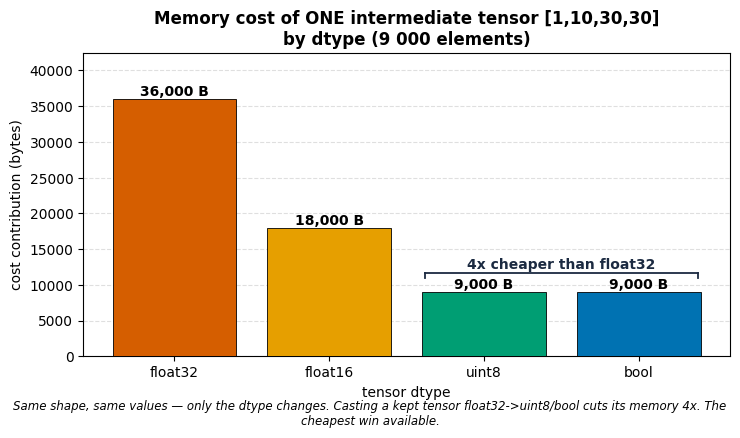

In [6]:
import matplotlib.pyplot as plt

N = 1*10*30*30  # 9000 elements in a [1,10,30,30] tensor
dtypes = [("float32",4,"#D55E00"),("float16",2,"#E69F00"),
          ("uint8",1,"#009E73"),("bool",1,"#0072B2")]
labels = [d[0] for d in dtypes]; costs = [N*d[1] for d in dtypes]; colors = [d[2] for d in dtypes]

fig, ax = plt.subplots(figsize=(7.5,4.2))
bars = ax.bar(labels, costs, color=colors, edgecolor="black", linewidth=0.6, zorder=3)
ax.set_title("Memory cost of ONE intermediate tensor [1,10,30,30]\nby dtype (9 000 elements)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("cost contribution (bytes)"); ax.set_xlabel("tensor dtype")
ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
for b,c in zip(bars,costs):
    ax.annotate(f"{c:,} B",(b.get_x()+b.get_width()/2,c),ha="center",va="bottom",fontsize=10,fontweight="bold")
ax.plot([1.62, 3.38], [11600, 11600], color="#1b2a41", lw=1.3)
ax.plot([1.62, 1.62], [11600, 10900], color="#1b2a41", lw=1.3)
ax.plot([3.38, 3.38], [11600, 10900], color="#1b2a41", lw=1.3)
ax.text(2.5, 12300, "4x cheaper than float32", ha="center", fontsize=10, color="#1b2a41", fontweight="bold")
ax.set_ylim(0,max(costs)*1.18)
fig.text(0.5,-0.02,"Same shape, same values — only the dtype changes. Casting a kept tensor "
   "float32->uint8/bool cuts its memory 4x. The cheapest win available.",
   ha="center",fontsize=8.5,style="italic",wrap=True)
fig.tight_layout(); plt.show()

### What one kept tensor actually costs

`input`/`output` are free; the first intermediate you *keep* dwarfs the whole `Conv`.

In [7]:
import pandas as pd
ELEM = 1*10*30*30
rows = [
    ("single Conv -> output",          900, 0,       "1 node, output is FREE -> memory 0"),
    ("Conv -> Relu -> output (fp32)",   900, ELEM*4,  "1 kept fp32 [1,10,30,30] = 36 000 B"),
    ("...same, intermediate in uint8",  900, ELEM*1,  "cast the kept tensor -> 4x less memory"),
]
df4 = pd.DataFrame(rows, columns=["graph","params","memory_B","why"])
df4.insert(3,"cost",df4["params"]+df4["memory_B"])
df4["points"] = df4["cost"].apply(lambda c: round(max(1.0,25-math.log(max(1,c))),2))
df4 = df4[["graph","params","memory_B","cost","points","why"]]
try:
    from IPython.display import display
    display(df4.style.format({"params":"{:,}","memory_B":"{:,}","cost":"{:,}","points":"{:.2f}"})
            .background_gradient(subset=["cost"],cmap="Reds").hide(axis="index")
            .set_caption("One kept intermediate costs ~40x the whole Conv. Drop it, or shrink its dtype."))
except Exception:
    print(df4.to_string(index=False))

graph,params,memory_B,cost,points,why
single Conv -> output,900,0,900,18.20,"1 node, output is FREE -> memory 0"
Conv -> Relu -> output (fp32),900,"36,000","36,900",14.48,"1 kept fp32 [1,10,30,30] = 36 000 B"
"...same, intermediate in uint8",900,"9,000","9,900",15.80,cast the kept tensor -> 4x less memory


### What the metric charges for (and what's free)

By now you've seen that `cost = params + memory` and that `input`/`output` are free by name. Two more things you might expect to pay for, but don't:

- **Compute is free.** MACs and FLOPs never enter the cost. A graph doing a billion multiply-adds scores the same as one doing ten, as long as the tensors are the same size. (The host eliminated MACs from the objective in the May 4 update, [#696953](https://www.kaggle.com/competitions/neurogolf-2026/discussion/696953): *"only cumulative memory footprint and parameter count will determine the cost of your networks."*)
- **Node count is free.** More nodes cost nothing by themselves. Only the tensors they keep alive are charged.

So the bill is the number and size of the intermediate tensors you keep, and nothing else. One handy consequence of `points = 25 − ln(cost)`: it is a straight line in log(cost), so a points target converts directly into a byte budget. The table reads it off; the curve shows the whole mapping.

points,cost = params + memory,that is about
24,3,3 B
22,20,20 B
20,148,148 B
18.5,665,665 B
16,"8,103",7.9 KB
14,"59,874",58.5 KB
12,"442,413",432.0 KB
10,"3,269,017",3.12 MB


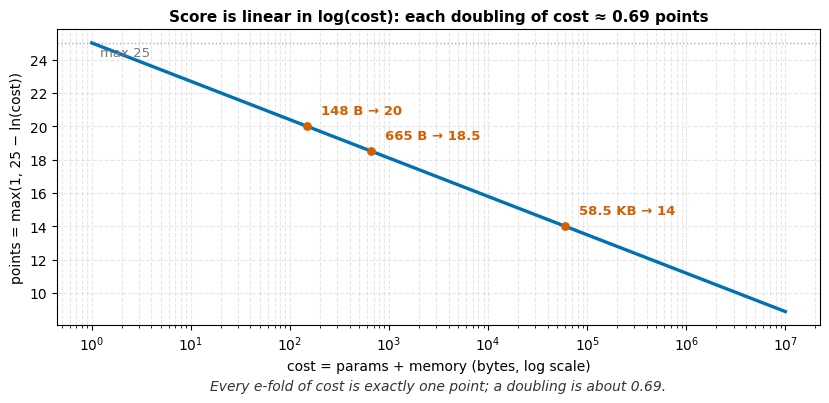

In [8]:
import numpy as np, pandas as pd, math
import matplotlib.pyplot as plt

# --- score <-> bytes: what each point level actually demands ---
def _human(c):
    return f"{c:,.0f} B" if c < 1024 else (f"{c/1024:,.1f} KB" if c < 1024**2 else f"{c/1024**2:,.2f} MB")
rows = [(p, f"{math.exp(25-p):,.0f}", _human(math.exp(25-p))) for p in [24, 22, 20, 18.5, 16, 14, 12, 10]]
dfm = pd.DataFrame(rows, columns=["points", "cost = params + memory", "that is about"])
try:
    from IPython.display import display
    display(dfm.style.hide(axis="index")
            .format({"points": "{:g}"})
            .background_gradient(subset=["points"], cmap="Greens")
            .set_properties(**{"font-size": "13px"})
            .set_table_styles([{"selector": "th", "props": [("background-color", "#333"), ("font-size", "13px"),
                ("color", "white"), ("text-align", "left")]}])
            .set_properties(**{"text-align": "left"})
            .set_caption("Read it either way: a points target is a hard byte budget. To score 20, a task's whole cost must fit in ~150 bytes."))
except Exception:
    print(dfm.to_string(index=False))

# --- the score curve: a straight line in log(cost) ---
cost = np.logspace(0, 7, 500); pts = np.maximum(1.0, 25.0 - np.log(cost))
fig, ax = plt.subplots(figsize=(8.4, 4.2))
ax.plot(cost, pts, color="#0072B2", lw=2.4, zorder=3)
ax.set_xscale("log")
ax.set_title("Score is linear in log(cost): each doubling of cost ≈ 0.69 points", fontsize=11, fontweight="bold")
ax.set_xlabel("cost = params + memory (bytes, log scale)"); ax.set_ylabel("points = max(1, 25 − ln(cost))")
ax.grid(True, which="both", ls="--", alpha=0.3)
ax.axhline(25, color="#aaaaaa", ls=":", lw=1); ax.text(1.2, 24.2, "max 25", fontsize=9.5, color="#777")
for c, lbl in [(148, "148 B → 20"), (665, "665 B → 18.5"), (59874, "58.5 KB → 14")]:
    p = max(1, 25 - math.log(c)); ax.scatter([c], [p], color="#D55E00", zorder=5, s=28)
    ax.annotate(lbl, (c, p), textcoords="offset points", xytext=(10, 9), fontsize=9.5, color="#D55E00", fontweight="bold")
ax.text(0.5, -0.22, "Every e-fold of cost is exactly one point; a doubling is about 0.69.",
        transform=ax.transAxes, ha="center", fontsize=10, style="italic", color="#333")
fig.tight_layout(); plt.show()

You can now put an exact price tag on any model. But a price only matters if the file *scores at all* — and the fastest way to score zero is a file the server refuses to load. Same runtime, different failure mode. Next we catch those **before** they reach the server.

<a id="part2"></a>
## Part 2 — Pre-submit validator (don't lose a whole submission to one file)

A single unscorable/erroring file makes the **entire** `submission.zip` score nothing. Run this over your 400 files **before** you submit. It flags, per file: load / `RUNTIME_ERROR`, `BANNED_OP`, `unscorable` (dynamic shapes, >1 input/output, custom domain, `If` bodies…), file-size overflow, and a `Conv` bias shorter than `out_channels`, which is invalid ONNX that nothing else catches. That last one is dissected below.

Static checkers (onnx shape-inference + a hand-maintained op blacklist) miss two things: a runtime that *loads* the op but **errors at inference**, and any op the blacklist author forgot (the real banned set includes `Compress`, every `*Sequence*` op, and `If` — easy to miss). Running the actual server runtime sidesteps both.

One caveat about inputs: an all-zero grid sends some `Gather`/`Slice` indices out of range and *falsely* fails files that are fine. If you pass `task_dir` (the competition data), the validator probes each file on its task's **own real example grids**, exactly what the grader uses, so runtime checks match the server. Without it, the validator falls back to random realistic grids and only flags a `RUNTIME_ERROR` when a file fails on *all* of them. Either way, structural failures (`BANNED_OP`, `unscorable`, file-size, load, `Conv`-bias length) do not depend on the input and are always exact.

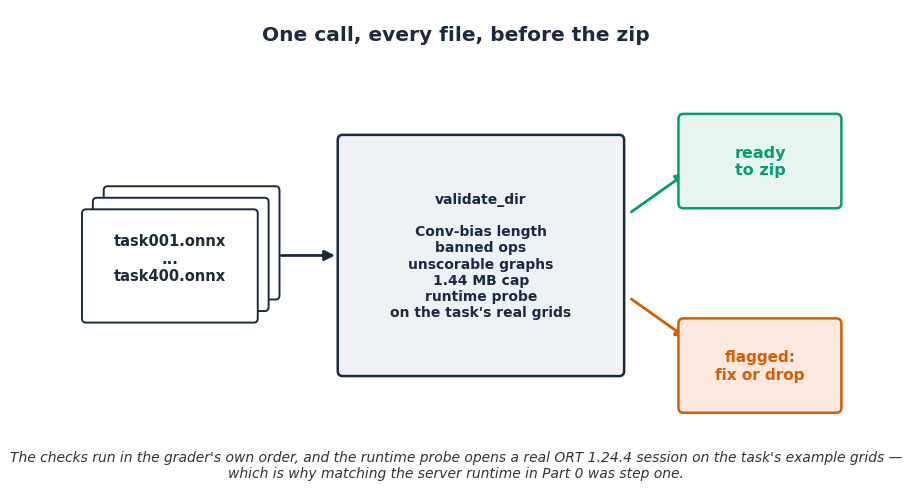

In [9]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

BLUE, VERM, GREEN, INK = "#0072B2", "#D55E00", "#009E73", "#1b2a41"

fig, ax = plt.subplots(figsize=(8.2, 4.6))
ax.set_xlim(0, 16); ax.set_ylim(2.3, 10.5); ax.axis("off")

ax.text(8, 9.9, "One call, every file, before the zip", ha="center", fontsize=14.5, fontweight="bold", color=INK)

def box(x, y, w, h, text, fc, ec, fs=11):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.1", fc=fc, ec=ec, lw=1.8))
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=fs, fontweight="bold", color=ec)

def arr(x0, y0, x1, y1, color=INK):
    ax.add_patch(FancyArrowPatch((x0, y0), (x1, y1), arrowstyle="-|>",
                                 mutation_scale=15, color=color, lw=2.0, shrinkA=2, shrinkB=2))

# the bundle (a small stack)
for k in range(2, -1, -1):
    off = k * 0.22
    ax.add_patch(FancyBboxPatch((0.5 + off, 4.6 + off), 3.4, 2.0, boxstyle="round,pad=0.08",
                                fc="white", ec=INK, lw=1.4))
ax.text(2.2, 5.75, "task001.onnx\n...\ntask400.onnx", ha="center", va="center", fontsize=10.5,
        fontweight="bold", color=INK)

arr(4.4, 5.8, 5.6, 5.8)

# the validator
box(5.7, 3.6, 5.6, 4.4, "validate_dir\n\nConv-bias length\nbanned ops\nunscorable graphs\n1.44 MB cap\nruntime probe\non the task's real grids", "#eef2f7", INK, 10)

arr(11.5, 6.6, 12.7, 7.4, GREEN)
arr(11.5, 5.0, 12.7, 4.2, VERM)
box(12.6, 6.8, 3.1, 1.6, "ready\nto zip", "#e8f5ee", GREEN, 11.5)
box(12.6, 2.9, 3.1, 1.6, "flagged:\nfix or drop", "#fbe9e0", VERM, 11)

fig.text(0.5, -0.05, "The checks run in the grader's own order, and the runtime probe opens a real ORT 1.24.4 session on the "
         "task's example grids —\nwhich is why matching the server runtime in Part 0 was step one.",
         ha="center", fontsize=10, style="italic", color="#333")
fig.tight_layout(); plt.show()

In [10]:
import glob

def check_conv_bias(model):
    """Conv/ConvTranspose nodes whose bias length != out_channels.

    A bias shorter than out_channels is invalid ONNX that every local tool passes, including this
    kit's own diagnose(). The section below shows why.
    Returns [(node, op_type, bias_len, out_channels), ...]; empty means clean.
    """
    init = {t.name: t for t in model.graph.initializer}
    bad = []
    for n in model.graph.node:
        if n.op_type not in ("Conv", "ConvTranspose") or len(n.input) < 3:
            continue                                        # the bias input is optional
        w, b = n.input[1], n.input[2]
        if w not in init or b not in init:
            continue                                        # non-static weight/bias: cannot check statically
        group = next((a.i for a in n.attribute if a.name == "group"), 1)
        dims = list(init[w].dims)                            # Conv [M,C/g,..] / ConvTranspose [C,M/g,..]
        out_ch = dims[0] if n.op_type == "Conv" else dims[1] * group
        blen = init[b].dims[0] if init[b].dims else 0
        if blen != out_ch:
            bad.append((n.name or n.op_type, n.op_type, int(blen), int(out_ch)))
    return bad

def _encode(grid):
    """One-hot encode an ARC grid (list of lists, colors 0-9) into [1,10,30,30]."""
    h, w = len(grid), len(grid[0])
    t = np.zeros((1,10,30,30), np.float32)
    for r in range(min(h,30)):
        for c in range(min(w,30)):
            v = grid[r][c]
            if 0 <= v < 10: t[0, v, r, c] = 1.0
    return t

def make_probe_grids(n=4, seed=0):
    """A few realistic non-empty ARC grids (varied size, random colors). Fallback when no task data."""
    rng = np.random.default_rng(seed)
    return [_encode(rng.integers(0,10,size=(int(rng.integers(2,31)),int(rng.integers(2,31)))).tolist())
            for _ in range(n)]

def real_grids_for(task_num, task_dir):
    """The task's OWN example inputs (what the grader actually scores on). None if unavailable."""
    p = os.path.join(task_dir, f"task{task_num:03d}.json")
    if not os.path.isfile(p): return None
    d = json.load(open(p))
    grids = []
    for ex in (d.get("train",[]) + d.get("test",[]))[:5]:
        g = ex["input"]
        if len(g) <= 30 and len(g[0]) <= 30: grids.append(_encode(g))
    return grids or None

def validate_dir(onnx_dir, task_dir=None, grids=None):
    """Returns (files, bad, points). With task_dir attached, each file is probed on its task's
    REAL example grids (exactly what the grader uses); otherwise on random realistic grids.
    Structural failures (BANNED_OP/unscorable/load/size) are input-independent and always exact."""
    probe = grids or make_probe_grids()
    files = sorted(glob.glob(os.path.join(onnx_dir, "task*.onnx")))
    if not files:
        print(f"WARNING: 0 task*.onnx files found in {onnx_dir} -- check the path / dataset attachment.")
    if task_dir is None:
        print("NOTE: no task_dir given -- runtime checks use random grids and may over-flag task-specialized "
              "graphs. Pass task_dir=<folder holding the competition's task*.json> for grader-exact runtime checks.")
    bad, points = [], {}
    for p in files:
        name = os.path.basename(p)
        cb = check_conv_bias(onnx.load(p))            # invalid bias length: every other check passes it
        if cb:
            _, _, blen, oc = cb[0]
            bad.append((name, f"CONV_BIAS {blen}!={oc}")); continue
        num = int("".join(ch for ch in name if ch.isdigit())[:3] or 0)
        use = (real_grids_for(num, task_dir) if task_dir else None) or probe
        runs = [score_onnx(p, g) for g in use]
        struct = next((r for r in runs if r["status"] != "ok"
                       and not r["status"].startswith("RUNTIME_ERROR")), None)
        if struct:                                   # input-independent failure
            bad.append((name, struct["status"])); continue
        if all(r["status"].startswith("RUNTIME_ERROR") for r in runs):
            bad.append((name, "RUNTIME_ERROR")); continue
        ok = next((r for r in runs if r["status"] == "ok"), None)
        if ok: points[name] = ok["points"]           # reuse the score, no re-run
    return files, bad, points

# demo: a clean file, a banned-op file, and a genuinely unscorable file
def build_banned():       # Compress is banned -> the whole submission would ERROR
    x,y=_io()
    cond = onnx.numpy_helper.from_array(np.ones((10,),bool),"c")
    g=oh.make_graph([oh.make_node("Compress",["input","c"],["output"],axis=1)],"g",[x],[y],[cond])
    return oh.make_model(g, opset_imports=[oh.make_opsetid("",17)], ir_version=8)

def build_unscorable():   # two graph outputs -> grader rejects (len(outputs) > 1) -> 'unscorable'
    x = oh.make_tensor_value_info("input",  TensorProto.FLOAT,[1,10,30,30])
    y = oh.make_tensor_value_info("output", TensorProto.FLOAT,[1,10,30,30])
    y2= oh.make_tensor_value_info("aux",    TensorProto.FLOAT,[1,10,30,30])
    nodes=[oh.make_node("Identity",["input"],["output"]),
           oh.make_node("Identity",["input"],["aux"])]
    g=oh.make_graph(nodes,"g",[x],[y,y2])
    return oh.make_model(g, opset_imports=[oh.make_opsetid("",17)], ir_version=8)

os.makedirs("/tmp/demo_sub", exist_ok=True)
onnx.save(build_single_conv(), "/tmp/demo_sub/task001.onnx")   # clean
onnx.save(build_banned(),      "/tmp/demo_sub/task002.onnx")   # banned op -> ERROR
onnx.save(build_unscorable(),  "/tmp/demo_sub/task003.onnx")   # unscorable (>1 output)
files, bad, points = validate_dir("/tmp/demo_sub")
print(f"checked {len(files)} files; problems: {len(bad)}")
for n, why in bad: print(f"  {n}: {why}")
print("\n=> fix or drop every flagged file BEFORE zipping. One bad file = zero for all 400.")

NOTE: no task_dir given -- runtime checks use random grids and may over-flag task-specialized graphs. Pass task_dir=<folder holding the competition's task*.json> for grader-exact runtime checks.
checked 3 files; problems: 2
  task002.onnx: BANNED_OP:Compress
  task003.onnx: unscorable

=> fix or drop every flagged file BEFORE zipping. One bad file = zero for all 400.


### From pass/fail to a diagnosis

The validator tells you a file fails. The next questions are *why*, and *how to fix it*. The grader runs every file through a fixed gauntlet, and a failing file exits at exactly one gate: load and size, the banned-op scan, a runtime probe (it actually runs the file on a real grid), then the scorability checks it uses to price the graph (static dims, one input and one output, no control-flow body, the default opset domain).

`diagnose()` below reports that gate, the specific cause, and the known fix. The demo builds one file per failure mode, runs the diagnosis on each, and draws the gauntlet so you can see where each one exits.

In [11]:
# diagnose(): pass/fail -> the gate a file dies at, the cause, and the fix.
# The grader runs each file through a fixed gauntlet, in this order: load & size,
# banned-op scan, a runtime probe (it actually runs the file), then the scorability
# checks it uses to price the graph. A file exits at exactly one gate.
import os, numpy as np, pandas as pd

_MAXB = int(1.44 * 1024 * 1024)

def diagnose(path, demo_input):
    name = os.path.basename(path)
    if os.path.getsize(path) > _MAXB:
        return dict(file=name, ok=False, stage="Load & size",
                    cause=f"{os.path.getsize(path)/1048576:.2f} MB over the 1.44 MB cap",
                    fix="shrink params: fp16 weights, drop dead initializers, or split the graph")
    try:
        m = onnx.load(path)
    except Exception as e:
        return dict(file=name, ok=False, stage="Load & size", cause=f"won't parse ({type(e).__name__})",
                    fix="re-export the model; the writer likely truncated or corrupted it")
    for node in m.graph.node:                                # If is NOT here -> caught later at Scorability
        if node.op_type.upper() in _EXCLUDED or "Sequence" in node.op_type:
            return dict(file=name, ok=False, stage="Op scan",
                        cause=f"op '{node.op_type}' is on the grader deny-list",
                        fix="express it with static-shape ops (Gather/Slice/Where/MaxPool/Conv)")
    try:                                                     # runtime probe runs BEFORE scoring (as the grader does)
        opts = ort.SessionOptions(); opts.log_severity_level = 4     # silence the expected probe error
        opts.graph_optimization_level = ort.GraphOptimizationLevel.ORT_DISABLE_ALL
        sess = ort.InferenceSession(path, opts, providers=["CPUExecutionProvider"])
        sess.run(None, {sess.get_inputs()[0].name: demo_input})
    except Exception as e:
        return dict(file=name, ok=False, stage="Runtime probe",
                    cause=f"loads but errors at inference ({type(e).__name__})",
                    fix="probe on the task's real grids (not zeros); clamp Gather/Slice indices; "
                        "if a Conv bias is shorter than out_channels, pad it (thread 699840)")
    try:
        g = onnx.shape_inference.infer_shapes(m, strict_mode=True).graph
    except Exception as e:
        return dict(file=name, ok=False, stage="Scorability", cause=f"shape inference fails ({type(e).__name__})",
                    fix="fix the graph so onnx shape-inference passes (often a bad Reshape/Concat)")
    for node in g.node:                                      # If/Loop carry a subgraph attribute -> unscorable
        for a in node.attribute:
            if a.type in (onnx.AttributeProto.GRAPH, onnx.AttributeProto.GRAPHS):
                return dict(file=name, ok=False, stage="Scorability", cause=f"control-flow body ({node.op_type})",
                            fix="unroll the branch to static ops; the grader rejects graph-body attributes")
    for op in m.opset_import:
        if op.domain not in {"", "ai.onnx"}:
            return dict(file=name, ok=False, stage="Scorability", cause=f"custom opset domain '{op.domain}'",
                        fix="use only the default ai.onnx domain")
    if len(g.input) > 1 or len(g.output) > 1:
        return dict(file=name, ok=False, stage="Scorability", cause=f"{len(g.input)} inputs / {len(g.output)} outputs",
                    fix="merge to exactly one 'input' and one 'output' tensor")
    for vi in list(g.input) + list(g.value_info) + list(g.output):
        if not vi.type.HasField("tensor_type"): continue
        tt = vi.type.tensor_type
        if not tt.HasField("shape"): continue
        for d in tt.shape.dim:
            if d.HasField("dim_param") or not d.HasField("dim_value") or d.dim_value <= 0:
                return dict(file=name, ok=False, stage="Scorability",
                            cause=f"tensor '{vi.name}' has a dynamic dim ('{d.dim_param or '?'}')",
                            fix="make every dim a fixed positive int; the grader rejects symbolic shapes")
    return dict(file=name, ok=True, stage="scorable", cause="passes every gate", fix="-")

# one demo file per failure mode (build_single_conv/build_banned/build_unscorable come from above)
def _build_dynamic_dim():
    x = oh.make_tensor_value_info("input",  TensorProto.FLOAT, [1, 10, 30, "W"])   # symbolic W
    y = oh.make_tensor_value_info("output", TensorProto.FLOAT, [1, 10, 30, "W"])
    return oh.make_model(oh.make_graph([oh.make_node("Identity", ["input"], ["output"])], "g", [x], [y]),
                         opset_imports=[oh.make_opsetid("", 17)], ir_version=8)
def _build_oversize():
    big = np.zeros((1000, 1000), np.float32)   # ~3.8 MB initializer, over the file cap
    x = oh.make_tensor_value_info("input",  TensorProto.FLOAT, [1, 1000])
    y = oh.make_tensor_value_info("output", TensorProto.FLOAT, [1, 1000])
    return oh.make_model(oh.make_graph([oh.make_node("MatMul", ["input", "Wbig"], ["output"])],
                         "g", [x], [y], [onnx.numpy_helper.from_array(big, "Wbig")]),
                         opset_imports=[oh.make_opsetid("", 17)], ir_version=8)
def _build_runtime_err():
    x = oh.make_tensor_value_info("input",  TensorProto.FLOAT, [1, 10, 30, 30])
    y = oh.make_tensor_value_info("output", TensorProto.FLOAT, [1, 10, 1, 30])
    idx = onnx.numpy_helper.from_array(np.array([50], np.int64), "idx")             # index OOB on an axis of size 30
    return oh.make_model(oh.make_graph([oh.make_node("Gather", ["input", "idx"], ["output"], axis=2)],
                         "g", [x], [y], [idx]), opset_imports=[oh.make_opsetid("", 17)], ir_version=8)

os.makedirs("/tmp/diag_demo", exist_ok=True)
_specs = [("task001.onnx", build_single_conv, demo), ("task002.onnx", build_banned, demo),
          ("task003.onnx", build_unscorable, demo), ("task004.onnx", _build_dynamic_dim, demo),
          ("task005.onnx", _build_oversize, np.zeros((1, 1000), np.float32)),
          ("task006.onnx", _build_runtime_err, demo)]
diags = []
for fn, b, di in _specs:
    p = f"/tmp/diag_demo/{fn}"; onnx.save(b(), p); diags.append(diagnose(p, di))


file,stage,cause,fix
task001.onnx,scorable,passes every gate,-
task002.onnx,Op scan,op 'Compress' is on the grader deny-list,express it with static-shape ops (Gather/Slice/Where/MaxPool/Conv)
task003.onnx,Scorability,1 inputs / 2 outputs,merge to exactly one 'input' and one 'output' tensor
task004.onnx,Scorability,tensor 'input' has a dynamic dim ('W'),make every dim a fixed positive int; the grader rejects symbolic shapes
task005.onnx,Load & size,3.81 MB over the 1.44 MB cap,"shrink params: fp16 weights, drop dead initializers, or split the graph"
task006.onnx,Runtime probe,loads but errors at inference (InvalidArgument),"probe on the task's real grids (not zeros); clamp Gather/Slice indices; if a Conv bias is shorter than out_channels, pad it (thread 699840)"


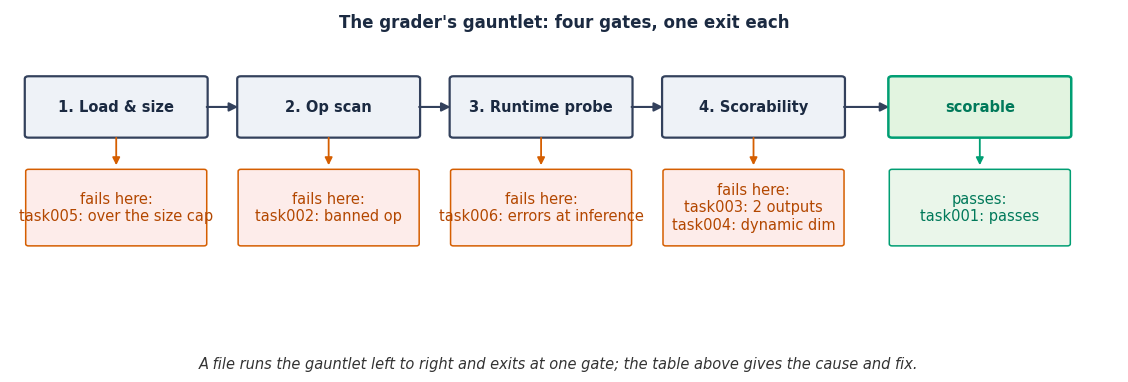

In [12]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
# --- table: gate / cause / fix per file ---
dfd = pd.DataFrame(diags)[["file", "stage", "cause", "fix"]]
def _dstyle(r):
    return [f"background-color:{'#e2f4e0' if r['stage']=='scorable' else '#fde0dc'}"] * len(r)
try:
    from IPython.display import display
    display(dfd.style.apply(_dstyle, axis=1).hide(axis="index")
            .set_properties(**{"font-size": "13px"})
            .set_table_styles([{"selector": "th", "props": [("background-color", "#333"), ("font-size", "13px"),
                ("color", "white"), ("text-align", "left")]}])
            .set_properties(**{"text-align": "left", "vertical-align": "top"})
            .set_properties(subset=["fix"], **{"white-space": "normal", "max-width": "360px"})
            .set_caption("Where each demo file exits the gauntlet, and how to fix it."))
except Exception:
    print(dfd.to_string(index=False))

# --- the gauntlet, drawn from the same diagnoses (same order the grader uses) ---
GATES = ["Load & size", "Op scan", "Runtime probe", "Scorability"]
def _short(d):
    s = d["stage"]
    if s == "Load & size":     lbl = "over the size cap" if "MB" in d["cause"] else "won't load"
    elif s == "Op scan":       lbl = "banned op"
    elif s == "Runtime probe": lbl = "errors at inference"
    elif s == "Scorability":   lbl = ("2 outputs" if "outputs" in d["cause"] else
                                      "dynamic dim" if "dynamic" in d["cause"] else
                                      "control-flow" if "control-flow" in d["cause"] else
                                      "custom domain" if "domain" in d["cause"] else "unscorable")
    else:                      lbl = "passes"
    return f"{d['file'].replace('.onnx','')}: {lbl}"
groups = [[_short(d) for d in diags if d["stage"] == gname] for gname in GATES]
passed = [_short(d) for d in diags if d["stage"] == "scorable"]
fig, ax = plt.subplots(figsize=(11.5, 3.6)); ax.set_xlim(0, 24); ax.set_ylim(0, 10); ax.axis("off")
xs = [2.3, 6.9, 11.5, 16.1, 21.0]; yb = 6.2; w, h = 3.8, 1.7
for i, gname in enumerate(GATES):
    cx = xs[i]
    ax.add_patch(FancyBboxPatch((cx-w/2, yb), w, h, boxstyle="round,pad=0.08", fc="#eef2f7", ec="#33415c", lw=1.6))
    ax.text(cx, yb+h/2, f"{i+1}. {gname}", ha="center", va="center", fontsize=10.5, fontweight="bold", color="#1b2a41")
    ax.add_patch(FancyArrowPatch((cx, yb), (cx, yb-1.0), arrowstyle="-|>", mutation_scale=11, color="#D55E00", lw=1.3))
    ax.add_patch(FancyBboxPatch((cx-w/2, yb-3.3), w, 2.2, boxstyle="round,pad=0.06", fc="#fdecea", ec="#D55E00", lw=1.1))
    ax.text(cx, yb-2.2, "fails here:\n" + ("\n".join(groups[i]) if groups[i] else "-"),
            ha="center", va="center", fontsize=10.5, color="#b34700")
    ax.add_patch(FancyArrowPatch((cx+w/2, yb+h/2), (xs[i+1]-w/2, yb+h/2), arrowstyle="-|>", mutation_scale=13, color="#33415c", lw=1.5))
cx = xs[4]
ax.add_patch(FancyBboxPatch((cx-w/2, yb), w, h, boxstyle="round,pad=0.08", fc="#e2f4e0", ec="#009E73", lw=1.8))
ax.text(cx, yb+h/2, "scorable", ha="center", va="center", fontsize=10.5, fontweight="bold", color="#00795a")
ax.add_patch(FancyArrowPatch((cx, yb), (cx, yb-1.0), arrowstyle="-|>", mutation_scale=11, color="#009E73", lw=1.3))
ax.add_patch(FancyBboxPatch((cx-w/2, yb-3.3), w, 2.2, boxstyle="round,pad=0.06", fc="#eaf6ea", ec="#009E73", lw=1.1))
ax.text(cx, yb-2.2, "passes:\n" + ("\n".join(passed) if passed else "-"), ha="center", va="center", fontsize=10.5, color="#00795a")
ax.text(12, 9.45, "The grader's gauntlet: four gates, one exit each", ha="center", fontsize=12, fontweight="bold", color="#1b2a41")
fig.text(0.5, -0.04, "A file runs the gauntlet left to right and exits at one gate; the table above gives the cause and fix.",
         ha="center", fontsize=10.5, style="italic", color="#333")
fig.tight_layout(); plt.show()

### The file that passes every gate — and still breaks your submission

`diagnose()` above mirrors the grader's gauntlet, and the file below clears all of it — `diagnose()` calls it *scorable, passes every gate*. That is precisely the problem.

The ONNX spec says a convolution's bias is 1-D of length `out_channels`. Give it fewer values and nothing on your machine objects: `onnx.checker` passes, strict shape-inference passes, and the pinned runtime runs it. The bias for the channels you never set is read from past the end of the buffer, which is undefined behaviour.

This is the bug that quietly destabilised scores at the top of this leaderboard. In [discussion 699840](https://www.kaggle.com/competitions/neurogolf-2026/discussion/699840) *robga* found the same ONNX files scoring differently depending only on their order inside the zip. *keymoon* traced it to an out-of-bounds read of uninitialised heap and explained why it hides so well: "[i]f ORT runs early in the process lifetime, the relevant memory region may still be filled with zeros". *Chris Deotte*, *David Austin*, *Chan Kha Vu* and *Yiheng Wang* all reported the same symptom, and the host filed [onnxruntime#28654](https://github.com/microsoft/onnxruntime/issues/28654) for the memory contamination underneath it. His own guidance: the scorer "appears to be working properly, provided that all Conv operations in submitted networks exhibit the proper length & bias values."

The two numbers the cell below prints for channels 8 and 9 are undefined. On my ARM64 laptop, both came back as exactly `0.0` and the decode flipped on both channels; the Kaggle session that rendered this page read whatever sat in its own memory — compare the printout below. Fork it and you may see something else again — same file, same ORT 1.24.4, different memory. That is what makes this bug so hard to catch by running the file.

So the runtime cannot warn you, and a clean local run proves nothing. A static check can, in a dozen lines of graph inspection. I have not found one in any public validator, so `validate_dir` above now runs `check_conv_bias` on every file.

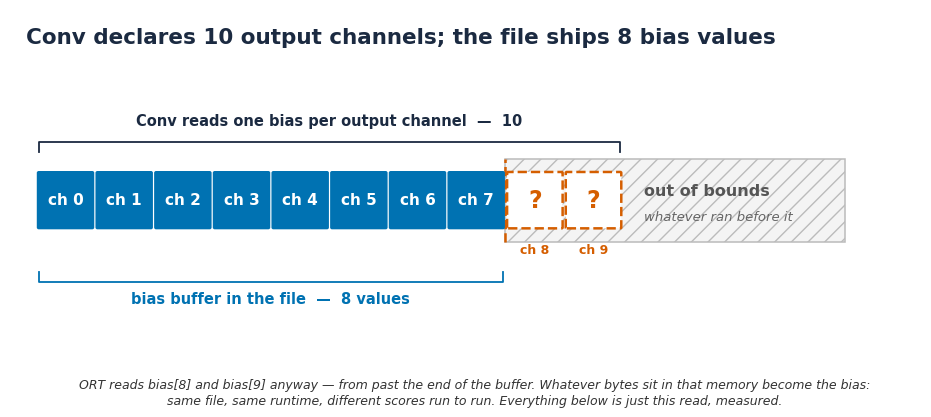

In [13]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle

# Okabe-Ito; every mark also labelled in words.
BLUE, VERM, INK = "#0072B2", "#D55E00", "#1b2a41"

fig, ax = plt.subplots(figsize=(9.6, 3.9))
ax.set_xlim(0, 17.4); ax.set_ylim(0, 7.6); ax.axis("off")

ax.text(0.3, 7.0, "Conv declares 10 output channels; the file ships 8 bias values",
        fontsize=15.5, fontweight="bold", color=INK, va="center")

x0, y0, w, h, gap = 0.55, 3.0, 1.02, 1.15, 0.1
cell  = lambda i: x0 + i * (w + gap)
buf_r = cell(7) + w
all_r = cell(9) + w

ax.add_patch(Rectangle((buf_r + 0.04, y0 - 0.3), 6.5, h + 0.6, fc="#f4f4f4", ec="#BBBBBB",
                       lw=1.1, hatch="//", zorder=0))
ax.plot([buf_r + 0.04, buf_r + 0.04], [y0 - 0.3, y0 + h + 0.3], color=VERM, lw=1.8, ls="--", zorder=1)

for i in range(10):
    x = cell(i)
    if i < 8:
        ax.add_patch(FancyBboxPatch((x, y0), w, h, boxstyle="round,pad=0.02", fc=BLUE, ec=BLUE, lw=1.4, zorder=2))
        ax.text(x + w/2, y0 + h/2, f"ch {i}", ha="center", va="center", fontsize=11,
                fontweight="bold", color="white", zorder=3)
    else:
        ax.add_patch(FancyBboxPatch((x, y0), w, h, boxstyle="round,pad=0.02", fc="white", ec=VERM,
                                    lw=1.8, linestyle="--", zorder=2))
        ax.text(x + w/2, y0 + h/2, "?", ha="center", va="center", fontsize=17,
                fontweight="bold", color=VERM, zorder=3)
        ax.text(x + w/2, y0 - 0.55, f"ch {i}", ha="center", fontsize=9, color=VERM, fontweight="bold", zorder=3)

ax.text(all_r + 0.45, y0 + h/2 + 0.2, "out of bounds", fontsize=11.5, fontweight="bold",
        color="#555", va="center", zorder=3)
ax.text(all_r + 0.45, y0 + h/2 - 0.35, "whatever ran before it", fontsize=9.5, style="italic",
        color="#666", va="center", zorder=3)

ax.plot([x0, x0, buf_r, buf_r], [y0 - 0.95, y0 - 1.15, y0 - 1.15, y0 - 0.95], color=BLUE, lw=1.3)
ax.text((x0 + buf_r)/2, y0 - 1.6, "bias buffer in the file  \u2014  8 values", ha="center",
        fontsize=10.5, color=BLUE, fontweight="bold")
ax.plot([x0, x0, all_r, all_r], [y0 + h + 0.45, y0 + h + 0.65, y0 + h + 0.65, y0 + h + 0.45], color=INK, lw=1.3)
ax.text((x0 + all_r)/2, y0 + h + 1.0, "Conv reads one bias per output channel  \u2014  10", ha="center",
        fontsize=10.5, color=INK, fontweight="bold")

fig.text(0.5, -0.05, "ORT reads bias[8] and bias[9] anyway \u2014 from past the end of the buffer. Whatever bytes sit in that "
         "memory become the bias:\nsame file, same runtime, different scores run to run. Everything below is just this read, measured.",
         ha="center", fontsize=9, style="italic", color="#333")
fig.tight_layout(); plt.show()

In [14]:
# Why check_conv_bias() has to exist: the bad file below clears every local gate.

def _conv_bias_demo(bias_len):
    """out_channels = 10, per-channel identity kernel. 10 bias values is correct; 8 is invalid ONNX."""
    W = np.zeros((10, 10, 3, 3), np.float32)
    for c in range(10): W[c, c, 1, 1] = 1.0
    B = (np.arange(bias_len) + 1).astype(np.float32)          # 1,2,3,... so each channel is legible
    x, y = _io()
    inits = [onnx.numpy_helper.from_array(W, "W"), onnx.numpy_helper.from_array(B, "B")]
    node = oh.make_node("Conv", ["input", "W", "B"], ["output"], pads=[1, 1, 1, 1], name="conv0")
    return oh.make_model(oh.make_graph([node], "g", [x], [y], inits),
                         opset_imports=[oh.make_opsetid("", 17)], ir_version=8)

def _bias_run(m):
    o = ort.SessionOptions(); o.log_severity_level = 4
    o.graph_optimization_level = ort.GraphOptimizationLevel.ORT_DISABLE_ALL
    s = ort.InferenceSession(m.SerializeToString(), o, providers=["CPUExecutionProvider"])
    return s.run(None, {"input": demo})[0]

def _verdict(m):
    v = {}
    for label, fn in (("onnx.checker",              lambda: onnx.checker.check_model(m)),
                      ("strict shape-inference",    lambda: onnx.shape_inference.infer_shapes(m, strict_mode=True)),
                      (f"ORT {ort.__version__} run", lambda: _bias_run(m))):
        try:
            fn(); v[label] = "pass"
        except Exception as e:
            v[label] = f"FAIL ({type(e).__name__})"
    onnx.save(m, "/tmp/bias_probe.onnx")                  # and this kit's own gauntlet, from Part 2
    v["diagnose() gauntlet"] = diagnose("/tmp/bias_probe.onnx", demo)["stage"]
    v["check_conv_bias"] = "FLAGGED" if check_conv_bias(m) else "clean"
    return v

good, bad = _conv_bias_demo(10), _conv_bias_demo(8)     # the only difference: two missing bias values
verdicts = {"correct bias (10)": _verdict(good), "short bias (8)": _verdict(bad)}

# What the missing bias actually does. At a corner where the input is zero, output == bias[channel].
applied = lambda o: [round(float(o[0, c, 29, 29]), 1) for c in range(10)]
og, ob = _bias_run(good), _bias_run(bad)
print("bias actually applied, per output channel:")
print("  correct:", applied(og))
print("  short  :", applied(ob))

# Channels 8 and 9 have no bias of their own. Print, exactly, what ORT read past the end of the buffer.
tail    = {c: float(ob[0, c, 29, 29]) for c in (8, 9)}
flipped = [c for c in range(10) if not np.array_equal(og[0, c] > 0, ob[0, c] > 0)]
flips   = int(((og > 0) != (ob > 0)).sum())

print("\n=> channels 8 and 9 were never given a bias. Past the end of the buffer, ORT read:")
for c, v in tail.items():
    print(f"     channel {c}: {v!r}")
print("   Those two values are undefined -- whatever the process happened to leave in that memory.")
if flips:
    print(f"   So the grader's decode (out > 0) changes on {flips:,} of {og.size:,} positions, "
          f"on channel(s) {flipped}.")
    print("   The graph that ran is not the graph you wrote, and nothing above said a word.")
else:
    print("   This run happened to read values that decode the same -- fork it and the dice roll again.")

def pad_conv_bias(model):
    """Zero-extend (or trim) every Conv/ConvTranspose bias to out_channels, in place.
    Padding ADDS parameters, so cost rises a little. Correctness first."""
    init = {t.name: t for t in model.graph.initializer}
    for n in model.graph.node:
        if n.op_type not in ("Conv", "ConvTranspose") or len(n.input) < 3: continue
        w, b = n.input[1], n.input[2]
        if w not in init or b not in init: continue
        group = next((a.i for a in n.attribute if a.name == "group"), 1)
        dims = list(init[w].dims)
        out_ch = dims[0] if n.op_type == "Conv" else dims[1] * group
        arr = onnx.numpy_helper.to_array(init[b])
        if arr.shape[0] == out_ch: continue
        fixed = np.zeros((out_ch,), arr.dtype); fixed[:min(out_ch, arr.shape[0])] = arr[:out_ch]
        init[b].CopyFrom(onnx.numpy_helper.from_array(fixed, init[b].name))
    return model

repaired = pad_conv_bias(_conv_bias_demo(8))
print("\nafter pad_conv_bias():", check_conv_bias(repaired) or "clean")

bias actually applied, per output channel:
  correct: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
  short  : [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 0.0, 0.0]

=> channels 8 and 9 were never given a bias. Past the end of the buffer, ORT read:
     channel 8: 0.0
     channel 9: 0.0
   Those two values are undefined -- whatever the process happened to leave in that memory.
   So the grader's decode (out > 0) changes on 1,800 of 9,000 positions, on channel(s) [8, 9].
   The graph that ran is not the graph you wrote, and nothing above said a word.

after pad_conv_bias(): clean


,correct bias (10),short bias (8)
onnx.checker,pass,pass
strict shape-inference,pass,pass
ORT 1.24.4 run,pass,pass
diagnose() gauntlet,scorable,scorable
check_conv_bias,clean,FLAGGED


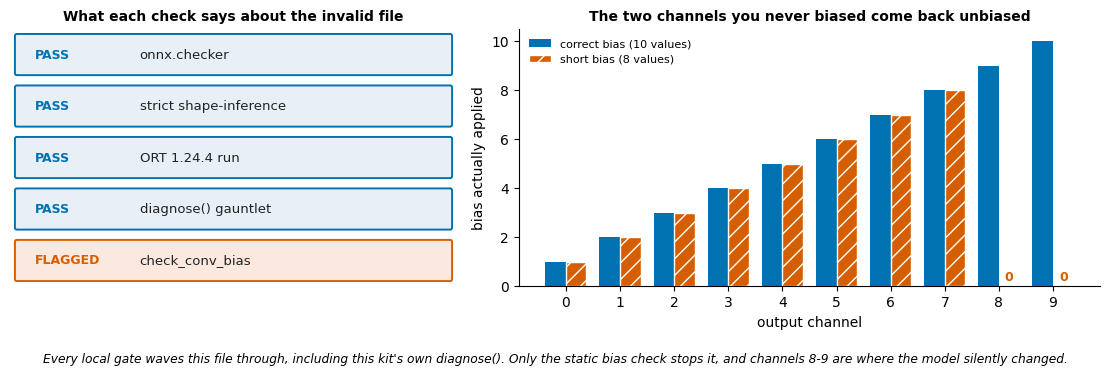

In [15]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from IPython.display import display

# Okabe-Ito: readable without colour vision, and every mark is also labelled in words.
BLUE, VERM = "#0072B2", "#D55E00"
vdf = pd.DataFrame(verdicts)
try:
    display(vdf.style
            .set_properties(**{"font-size": "13px"})
            .set_table_styles([{"selector": "th", "props": [("background-color", "#333"), ("font-size", "13px"),
                ("color", "white"), ("text-align", "left")]}])
            .set_properties(**{"text-align": "left"})
            .set_caption("Five checks, two files. onnx.checker, shape-inference, ORT 1.24.4 and diagnose() pass both; "
                         "only check_conv_bias tells the valid file from the invalid one."))
except Exception:
    print(vdf.to_string())
_vb = verdicts["short bias (8)"]
_ca, _sa = applied(og), applied(ob)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11.2, 3.5), gridspec_kw={"width_ratios": [1, 1.3]})

axL.set_xlim(0, 10); axL.set_ylim(0, len(_vb)); axL.axis("off")
for k, (lab, v) in enumerate(_vb.items()):
    y, ok = len(_vb) - k - 1, (v in ("pass", "scorable"))
    fc, ec = ("#e7f0f7", BLUE) if ok else ("#fbe9e0", VERM)
    axL.add_patch(FancyBboxPatch((0.15, y + 0.14), 9.7, 0.72, boxstyle="round,pad=0.04", fc=fc, ec=ec, lw=1.4))
    axL.text(0.55, y + 0.5, "PASS" if ok else "FLAGGED", va="center", fontsize=9, fontweight="bold", color=ec)
    axL.text(2.9, y + 0.5, lab, va="center", fontsize=9.5, color="#222")
axL.set_title("What each check says about the invalid file", fontsize=10, fontweight="bold")

import numpy as _np
ch, w = _np.arange(10), 0.38
axR.bar(ch - w / 2, _ca, w, label="correct bias (10 values)", color=BLUE)
axR.bar(ch + w / 2, _sa, w, label="short bias (8 values)", color=VERM, hatch="//", edgecolor="white")
for c in (8, 9):
    axR.annotate(f"{_sa[c]:g}", (c + w / 2, 0.25), ha="center", fontsize=9, fontweight="bold", color=VERM)
axR.set_xticks(ch); axR.set_xlabel("output channel"); axR.set_ylabel("bias actually applied")
axR.set_title("The two channels you never biased come back unbiased", fontsize=10, fontweight="bold")
axR.legend(fontsize=8, frameon=False, loc="upper left")
axR.spines[["top", "right"]].set_visible(False)

fig.text(0.5, -0.05, "Every local gate waves this file through, including this kit's own diagnose(). "
         "Only the static bias check stops it, and channels 8-9 are where the model silently changed.",
         ha="center", fontsize=8.8, style="italic")
fig.tight_layout(); plt.show()


The diagnosis tells you *why* a file fails. A separate question is *which ops are safe* to build with in the first place. So before you spend a day rewriting a graph to dodge an op you heard was banned, check whether it actually is.

<a id="part3"></a>
## Part 3 — Myth-busting: which ops actually run on the server?

The **explicitly banned** set is small: `Loop, Scan, NonZero, Unique, Script, Function, Compress`, anything whose name contains `Sequence`, plus `If` (graph-body attributes). Everything else is allowed *if it loads on the server runtime*.

A widely repeated claim is that **`TopK` is unusable**. On the pinned runtime it runs fine — I probe it live below. (My original `ERROR` was a *specific* `TopK` construction, not the op itself.) The lesson: don't ban an op from hearsay — **probe it**.

In [16]:
def op_runs(make_model_fn, demo_input):
    try:
        onnx.save(make_model_fn(), "/tmp/probe.onnx")
        return score_onnx("/tmp/probe.onnx", demo_input)["status"]
    except Exception as e:
        return f"BUILD_ERROR:{type(e).__name__}"

def build_topk():   # TopK over the channel axis (k=1) -> [1,1,30,30]. Probes that the op runs.
    x = oh.make_tensor_value_info("input", TensorProto.FLOAT,[1,10,30,30])
    y = oh.make_tensor_value_info("output",TensorProto.FLOAT,[1,1,30,30])
    k = onnx.numpy_helper.from_array(np.array([1],np.int64),"k")
    nodes=[oh.make_node("TopK",["input","k"],["vals","idx"],axis=1),
           oh.make_node("Cast",["vals"],["output"],to=TensorProto.FLOAT)]
    g=oh.make_graph(nodes,"g",[x],[y],[k])
    return oh.make_model(g, opset_imports=[oh.make_opsetid("",17)], ir_version=8)

print("TopK status on the pinned runtime:", op_runs(build_topk, demo))
print("=> if this prints 'ok', TopK scores fine. Always re-check YOUR specific construction with validate_dir.")

TopK status on the pinned runtime: ok
=> if this prints 'ok', TopK scores fine. Always re-check YOUR specific construction with validate_dir.


### Op safety cheat-sheet (server ORT 1.24.4)

The banned set is small and explicit. Everything else is allowed *if it loads*. The `ok*` rows are the ones to **probe on a real grid** before you rely on them.

In [17]:
import pandas as pd
op_rows = [
 ("Loop","BANNED","Explicit deny-list (control flow)."),
 ("Scan","BANNED","Explicit deny-list (control flow)."),
 ("NonZero","BANNED","Explicit deny-list (dynamic output shape)."),
 ("Unique","BANNED","Explicit deny-list (dynamic output shape)."),
 ("Compress","BANNED","Explicit deny-list (dynamic output shape)."),
 ("If","BANNED","Graph-body attribute -> unscorable (rejected by the cost pass)."),
 ("*Sequence*","BANNED","Any op whose name contains 'Sequence'."),
 ("Script / Function","BANNED","Custom domains / model.functions rejected."),
 ("TopK","ok*","Runs fine on 1.24.4. The 'TopK is banned' myth is false."),
 ("Conv","ok","Core op. Watch the OUTPUT tensor size (that is memory)."),
 ("MatMul","ok","Core op. Cheap if you keep dims small."),
 ("Einsum","ok*","Runs; some equations slow but score fine."),
 ("Gather","ok*","Probe on a REAL grid — zeros can OOB the indices."),
 ("Slice","ok*","Same: validate on a real input, not np.zeros."),
 ("Pad","ok","Free trick: pad at the very END keeps tensors small."),
 ("MaxPool","ok","Core op, fine."),
 ("ScatterElements","ok","Runs on 1.24.4; verify the output shape is static."),
]
dfop = pd.DataFrame(op_rows, columns=["Op","Status","Note"])
def _rowstyle(r):
    s=r["Status"]; bg="#fde0dc" if s=="BANNED" else "#fff4cc" if s.endswith("*") else "#e2f4e0"
    return [f"background-color:{bg}"]*len(r)
try:
    from IPython.display import display
    display(dfop.style.apply(_rowstyle,axis=1).hide(axis="index")
            .set_table_styles([{"selector":"th","props":[("background-color","#333"),
                ("color","white"),("text-align","left")]}])
            .set_properties(**{"text-align":"left"})
            .set_caption("Op safety on the scoring server (ORT 1.24.4). ok* = allowed but PROBE it on a real grid first."))
except Exception:
    print(dfop.to_string(index=False))

Op,Status,Note
Loop,BANNED,Explicit deny-list (control flow).
Scan,BANNED,Explicit deny-list (control flow).
NonZero,BANNED,Explicit deny-list (dynamic output shape).
Unique,BANNED,Explicit deny-list (dynamic output shape).
Compress,BANNED,Explicit deny-list (dynamic output shape).
If,BANNED,Graph-body attribute -> unscorable (rejected by the cost pass).
*Sequence*,BANNED,Any op whose name contains 'Sequence'.
Script / Function,BANNED,Custom domains / model.functions rejected.
TopK,ok*,Runs fine on 1.24.4. The 'TopK is banned' myth is false.
Conv,ok,Core op. Watch the OUTPUT tensor size (that is memory).


### Myth: you have to target opset 10

A lot of starter graphs are pinned to opset 10 and people treat it as a hard limit. It isn't. After the May 4 update dropped `onnx_tool`, the host noted in [the same thread](https://www.kaggle.com/competitions/neurogolf-2026/discussion/696953) that the scorer depends only on numpy, onnx, and onnxruntime, and *"we don't explicitly enforce any restrictions"* on IR version or opset. Recent opsets load and score fine; every demo in this notebook is opset 17, and the table below scores the same graph at opset 10 and opset 17 to the same number.

Moving up doesn't make a kept tensor cheaper: the demo keeps one in `uint8` at opset 10 at the same cost. The gain is in the *other* ops. A recent opset widens which ops accept narrow dtypes. Andrey Yunoshev notes in [713210](https://www.kaggle.com/competitions/neurogolf-2026/discussion/713210) that *"opset ≥14 unlocks cheap uint8 ops"*, so you can do the math in the cheap dtype instead of casting back to `float32`. I checked: `Add` on `uint8` is rejected at opset 10-13 and valid at 14+. Since the grader bills memory by bytes and `uint8` is a quarter of `float32`, the opset that keeps you in the small dtype end to end is the one to target.

In [18]:
import pandas as pd

def _keep_one(opset, dt):   # a graph that keeps exactly one intermediate 'mid' at dtype dt
    x = oh.make_tensor_value_info("input",  TensorProto.FLOAT, [1, 10, 30, 30])
    y = oh.make_tensor_value_info("output", TensorProto.FLOAT, [1, 10, 30, 30])
    nodes = [oh.make_node("Cast", ["input"], ["mid"], to=dt),
             oh.make_node("Cast", ["mid"], ["output"], to=TensorProto.FLOAT)]
    return oh.make_model(oh.make_graph(nodes, "g", [x], [y]),
                         opset_imports=[oh.make_opsetid("", opset)], ir_version=8)

rows = []
for opset, dt, nm in [(10, TensorProto.UINT8, "uint8"), (17, TensorProto.UINT8, "uint8"),
                      (17, TensorProto.FLOAT, "float32")]:
    onnx.save(_keep_one(opset, dt), "/tmp/opset_probe.onnx")
    r = score_onnx("/tmp/opset_probe.onnx", demo)
    rows.append((f"opset {opset}", nm, r["status"], f"{r['memory']:,} B"))
dfo = pd.DataFrame(rows, columns=["opset", "kept dtype", "status", "kept-tensor cost"])

print("=> don't cargo-cult opset 10. Target the opset your ops need, and keep each tensor in the smallest dtype it allows.")

=> don't cargo-cult opset 10. Target the opset your ops need, and keep each tensor in the smallest dtype it allows.


In [19]:
def _ostyle(r):
    return [f"background-color:{'#e2f4e0' if r['kept dtype']=='uint8' else '#fff4cc'}"] * len(r)
try:
    from IPython.display import display
    display(dfo.style.apply(_ostyle, axis=1).hide(axis="index")
            .set_properties(**{"font-size": "13px"})
            .set_table_styles([{"selector": "th", "props": [("background-color", "#333"), ("font-size", "13px"),
                ("color", "white"), ("text-align", "left")]}])
            .set_properties(**{"text-align": "left"})
            .set_caption("opset 10 and opset 17 score identically (ok). The cost lives in the dtype: uint8 is 4x cheaper than float32. The amber row is costlier, not unsafe."))
except Exception:
    print(dfo.to_string(index=False))


opset,kept dtype,status,kept-tensor cost
opset 10,uint8,ok,"9,000 B"
opset 17,uint8,ok,"9,000 B"
opset 17,float32,ok,"36,000 B"


Cost, validity and op-safety are all reproducible now. The last question is strategic: given a fixed budget, *where* does the cost concentrate? That tells you which tasks to spend your surgery time on.

<a id="part4"></a>
## Part 4 — Where does the cost actually hide?

Score is `25 − ln(cost)`, which is logarithmic, so a handful of expensive tasks hold most of the recoverable points. This notebook has a public ONNX bundle attached, so the cell below computes the real per-task cost with the exact scorer from Part 1 (scoring each file on its task's own example grid) and plots the distribution alongside the 15-task worklist. If you fork without a bundle, it falls back to a synthetic distribution so Run All still shows the shape of the problem.

No ONNX bundle attached -- showing a SYNTHETIC cost distribution (attach a public bundle for the real one).


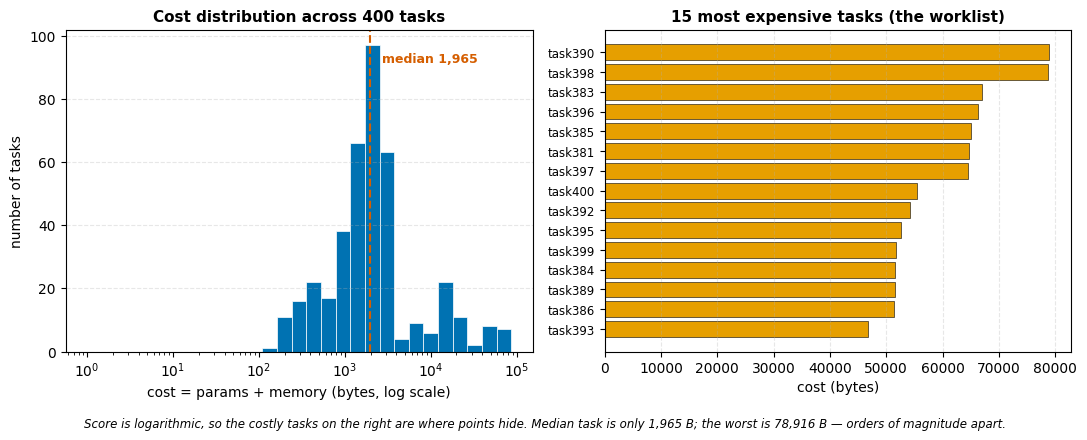

In [20]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, glob, os

def _gather_costs():
    # compute live from any attached folder of task*.onnx using Part-1's score_onnx,
    # scoring each file on its task's REAL example grid when the competition data is attached.
    onnx_dir=None
    for d in ["/kaggle/input"]:
        hit=sorted(glob.glob(os.path.join(d,"**","task*.onnx"),recursive=True))
        if hit: onnx_dir=os.path.dirname(hit[0]); break
    if onnx_dir is None: return None
    task_dir=next(iter(glob.glob("/kaggle/input/**/task001.json",recursive=True)), None)
    task_dir=os.path.dirname(task_dir) if task_dir else None
    fallback=np.zeros((1,10,30,30),np.float32); fallback[0,0,0,0]=1.0
    out=[]
    files=sorted(glob.glob(os.path.join(onnx_dir,"task*.onnx")))
    for p in files:
        num=int("".join(ch for ch in os.path.basename(p) if ch.isdigit())[:3] or 0)
        rg=(real_grids_for(num, task_dir) if task_dir else None)
        r=score_onnx(p, rg[0] if rg else fallback)
        if r.get("status")=="ok" and r.get("cost") is not None:
            out.append((num, r["cost"]))
    print(f"scored {len(out)}/{len(files)} files on {'real example' if task_dir else 'fallback'} grids")
    return pd.DataFrame(out,columns=["task","cost"]) if out else None

dfc=_gather_costs()
if dfc is None or len(dfc)==0:
    # synthetic fallback: skewed costs so the log-scale story still renders on a bare Run All
    rng=np.random.default_rng(0)
    synth=np.concatenate([rng.integers(150,3000,330), rng.integers(3000,20000,50), rng.integers(20000,80000,20)])
    dfc=pd.DataFrame({"task":np.arange(1,len(synth)+1),"cost":synth})
    print("No ONNX bundle attached -- showing a SYNTHETIC cost distribution (attach a public bundle for the real one).")

costs=np.sort(dfc["cost"].values); cclip=np.clip(costs,1,None); med=int(np.median(costs))
fig,(axA,axB)=plt.subplots(1,2,figsize=(11,4.2))
bins=np.logspace(0,np.log10(cclip.max()*1.1),30)
axA.hist(cclip,bins=bins,color="#0072B2",edgecolor="white",linewidth=0.5)
axA.set_xscale("log")
axA.set_title(f"Cost distribution across {len(costs)} tasks",fontsize=11,fontweight="bold")
axA.set_xlabel("cost = params + memory (bytes, log scale)"); axA.set_ylabel("number of tasks")
axA.axvline(med,color="#D55E00",ls="--",lw=1.5)
axA.annotate(f"median {med:,}",xy=(med,axA.get_ylim()[1]*0.9),xytext=(med*1.4,axA.get_ylim()[1]*0.9),
             color="#D55E00",fontsize=9,fontweight="bold")
axA.grid(axis="y",ls="--",alpha=0.3)
top=dfc.sort_values("cost",ascending=False).head(15)
axB.barh(range(len(top)),top["cost"].values[::-1],color="#E69F00",edgecolor="black",linewidth=0.4)
axB.set_yticks(range(len(top)))
axB.set_yticklabels([f"task{int(t):03d}" for t in top["task"].values[::-1]],fontsize=8.5)
axB.set_title("15 most expensive tasks (the worklist)",fontsize=11,fontweight="bold")
axB.set_xlabel("cost (bytes)"); axB.grid(axis="x",ls="--",alpha=0.3)
fig.text(0.5,-0.03,f"Score is logarithmic, so the costly tasks on the right are where points hide. "
   f"Median task is only {med:,} B; the worst is {int(costs.max()):,} B — orders of magnitude apart.",
   ha="center",fontsize=8.5,style="italic")
fig.tight_layout(); plt.show()

<a id="use-it"></a>
## Use it on your own submission

One call before you zip. Point `validate_dir` at your folder of `task001.onnx … task400.onnx`. Attach the competition data too, and it probes each file on its task's **real example grids** (exactly what the grader scores on), flags every file that would `ERROR`, and returns the local points for the clean ones. Set the two paths and run.

In [21]:
YOUR_DIR = "/kaggle/input/your-bundle/submission"        # TWEAK THIS: any folder of task*.onnx files works
_hits = glob.glob("/kaggle/input/**/task001.json", recursive=True)   # the competition data, wherever Kaggle mounts it
TASK_DIR = os.path.dirname(_hits[0]) if _hits else None                # None -> validator falls back to random probe grids

if not glob.glob(os.path.join(YOUR_DIR, "task*.onnx")):
    print("Set YOUR_DIR to a folder of task*.onnx (attach a public bundle or your own as input).")
else:
    td = TASK_DIR
    files, bad, points = validate_dir(YOUR_DIR, task_dir=td)   # scores reused, no double run
    print(f"{len(files)} files | {len(bad)} would ERROR | local score ~ {sum(points.values()):.1f}")
    for n, why in bad[:10]: print("  fix:", n, why)
    print("Zip and submit only once 'would ERROR' is 0.")

Set YOUR_DIR to a folder of task*.onnx (attach a public bundle or your own as input).


<a id="silent-zero"></a>
## The one failure the validator can't catch: the silent zero

The validator above flags files that error, use a banned op, or can't be scored. It can't flag a file that runs perfectly and is simply *wrong* on the hidden test. It shows up like this: a file passes every public example (train, test, and the ARC-GEN samples) and still contributes **0**. No error, just a silent zero.

Here is why. The hidden set is generated by the same ARC-GEN generators as the public data, only with different seeds. If a file learned the *public examples* instead of the *transformation*, it works on what you can see and breaks on what you can't.

The check that catches it: before spending a submission, run each file on samples it has never seen. If it fails on fresh samples from the same generator, it would fail on the hidden set too.

The gate code below is a self-contained illustration on a toy task (swap colors 1 and 2). The "correct" model does the real swap. The "overfit" model only learned 1 → 2, because the public example inputs here happen to contain no color 2. Both pass the public examples; only the overfit one fails on fresh samples. That is the silent zero, reproduced.

During the competition I ran a full version of this against the ARC-GEN generators across all 400 tasks before every submission, and it caught real files that looked fine locally. The demo below is the whole idea; the only extra step is matching each task to its generator, which I kept private while the competition was live. The 6th-place team ran the same gate at 1000 fresh samples — see [what the winners did](#winners).

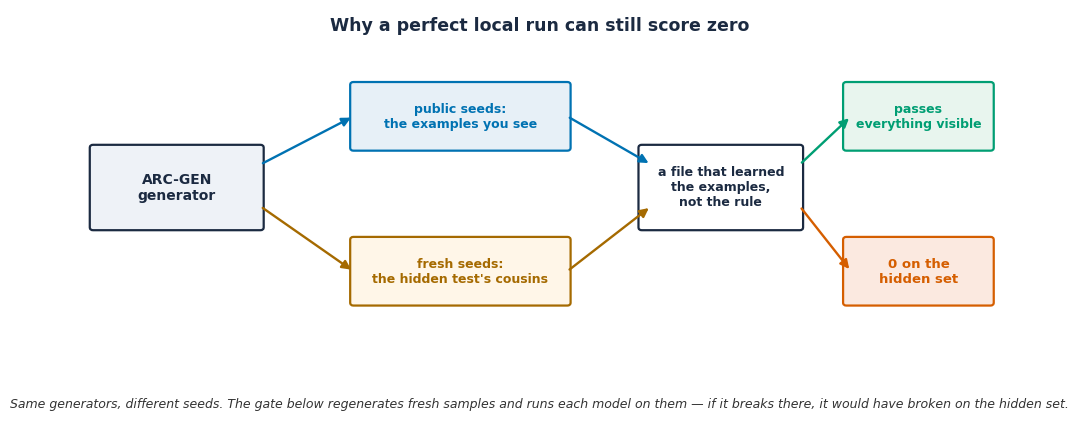

In [22]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

BLUE, VERM, GREEN, INK, GREY = "#0072B2", "#D55E00", "#009E73", "#1b2a41", "#8a8a8a"

fig, ax = plt.subplots(figsize=(9.6, 3.9))
ax.set_xlim(0, 20); ax.set_ylim(0, 8.6); ax.axis("off")

ax.text(10, 8.1, "Why a perfect local run can still score zero", ha="center",
        fontsize=12.5, fontweight="bold", color=INK)

def box(x, y, w, h, text, fc, ec, fs=9.5, tc=None):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.07", fc=fc, ec=ec, lw=1.6))
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=fs,
            fontweight="bold", color=tc or ec)

def arrow(x0, y0, x1, y1, color=INK, lw=1.7, style="-|>"):
    ax.add_patch(FancyArrowPatch((x0, y0), (x1, y1), arrowstyle=style,
                                 mutation_scale=13, color=color, lw=lw))

# one generator, two seed streams
box(0.4, 3.4, 3.6, 1.9, "ARC-GEN\ngenerator", "#eef2f7", INK, 10)
box(6.0, 5.3, 4.6, 1.5, "public seeds:\nthe examples you see", "#e7f0f7", BLUE, 9)
box(6.0, 1.6, 4.6, 1.5, "fresh seeds:\nthe hidden test's cousins", "#fff6e8", "#a56a00", 9)
arrow(4.0, 4.9, 6.0, 6.05, BLUE)
arrow(4.0, 3.9, 6.0, 2.35, "#a56a00")

# the overfit model, two outcomes
box(12.2, 3.4, 3.4, 1.9, "a file that learned\nthe examples,\nnot the rule", "white", INK, 9)
arrow(10.6, 6.05, 12.4, 4.9, BLUE)
arrow(10.6, 2.35, 12.4, 3.9, "#a56a00")

box(16.6, 5.3, 3.1, 1.5, "passes\neverything visible", "#e8f5ee", GREEN, 9)
box(16.6, 1.6, 3.1, 1.5, "0 on the\nhidden set", "#fbe9e0", VERM, 9.5)
arrow(15.6, 4.9, 16.7, 6.05, GREEN)
arrow(15.6, 3.9, 16.7, 2.35, VERM)

fig.text(0.5, -0.06, "Same generators, different seeds. The gate below regenerates fresh samples and runs each model on them "
         "— if it breaks there, it would have broken on the hidden set.",
         ha="center", fontsize=9, style="italic", color="#333")
fig.tight_layout()
plt.show()

In [23]:
# The silent-zero gate (concept + a self-contained demo).
# The validator catches ERRORs; it can't catch a file that runs fine but is WRONG on the
# hidden set. The hidden set is the SAME ARC-GEN generators with NEW seeds, so the check is:
# does the file still match on samples it has never seen?
import numpy as np, pandas as pd

def _matches(out, expected):
    """Official decode: pred = (out > 0) per channel, compared to the one-hot of expected."""
    e = np.asarray(expected, np.int64); oh_, ow = e.shape
    pred = out[0] > 0.0
    exp = np.zeros((10, 30, 30), bool)
    r, c = np.indices((oh_, ow)); exp[e.ravel(), r.ravel(), c.ravel()] = True
    return np.array_equal(pred, exp)

def _swap12(g):                       # toy task: swap colors 1 and 2
    g = np.asarray(g); o = g.copy(); o[g == 1] = 2; o[g == 2] = 1; return o.tolist()

rng = np.random.default_rng(0)        # public example inputs here use only colors {0, 1}
public = [{"input": (gi := rng.integers(0, 2, (4, 4)).tolist()), "output": _swap12(gi)} for _ in range(3)]
fresh, s = [], 1000                   # fresh inputs include color 2
while len(fresh) < 12:
    r = np.random.default_rng(s); s += 1; gi = r.integers(0, 3, (4, 4))
    if (gi == 2).any(): fresh.append({"input": gi.tolist(), "output": _swap12(gi)})

def _remap(W2d):                      # 1x1 Conv channel remap (no bias), built like the demos above
    Wt = np.asarray(W2d, np.float32).reshape(10, 10, 1, 1)
    x = oh.make_tensor_value_info("input",  TensorProto.FLOAT, [1, 10, 30, 30])
    y = oh.make_tensor_value_info("output", TensorProto.FLOAT, [1, 10, 30, 30])
    g = oh.make_graph([oh.make_node("Conv", ["input", "W"], ["output"], kernel_shape=[1, 1])],
                      "g", [x], [y], [onnx.numpy_helper.from_array(Wt, "W")])
    m = oh.make_model(g, opset_imports=[oh.make_opsetid("", 17)], ir_version=8)
    return ort.InferenceSession(m.SerializeToString(), providers=["CPUExecutionProvider"])

eye = np.eye(10, dtype=np.float32)
correct = eye.copy(); correct[1, 1] = correct[2, 2] = 0; correct[1, 2] = correct[2, 1] = 1   # full 1<->2 swap
overfit = eye.copy(); overfit[1, 1] = 0; overfit[2, 1] = 1                                    # only 1->2 (color 2 untouched)
sess_correct, sess_overfit = _remap(correct), _remap(overfit)

def _run(sess, grid):                 # _encode (one-hot) comes from Part 2
    return sess.run(None, {sess.get_inputs()[0].name: _encode(grid)})[0]
def _passes(sess, pairs):
    return all(_matches(_run(sess, p["input"]), p["output"]) for p in pairs)

# --- verdict table: both pass the PUBLIC examples; only fresh seeds expose the overfit ---
rows = []
for label, sess in [("Correct model (full 1<->2 swap)", sess_correct),
                    ("Overfit model (only learned 1->2)", sess_overfit)]:
    pub, fr = _passes(sess, public), _passes(sess, fresh)
    verdict = "clean" if (pub and fr) else ("OVERFIT - silent zero on the hidden set" if pub else "broken")
    rows.append((label, "pass" if pub else "FAIL", "pass" if fr else "FAIL", verdict))
dfg = pd.DataFrame(rows, columns=["model", "public examples", "fresh seeds", "verdict"])


model,public examples,fresh seeds,verdict
Correct model (full 1<->2 swap),pass,pass,clean
Overfit model (only learned 1->2),pass,FAIL,OVERFIT - silent zero on the hidden set


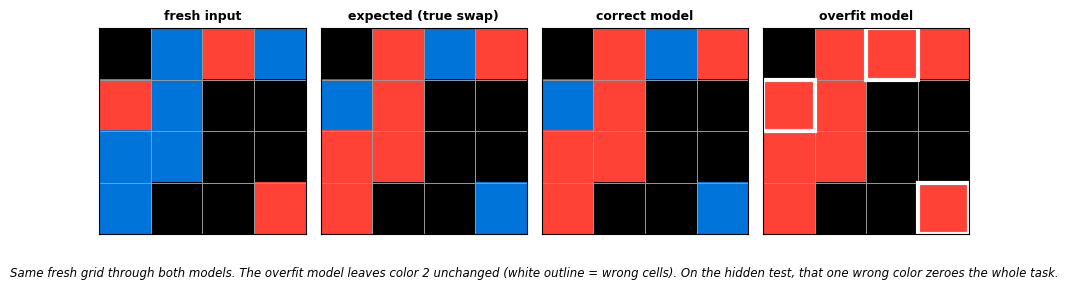

In [24]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Rectangle

def _vstyle(r):
    bg = "#e2f4e0" if r["verdict"] == "clean" else "#fde0dc"
    return [f"background-color:{bg}"] * len(r)
try:
    from IPython.display import display
    display(dfg.style.apply(_vstyle, axis=1).hide(axis="index")
            .set_properties(**{"font-size": "13px"})
            .set_table_styles([{"selector": "th", "props": [("background-color", "#333"), ("font-size", "13px"),
                ("color", "white"), ("text-align", "left")]}])
            .set_properties(**{"text-align": "left"})
            .set_caption("Both models pass every PUBLIC example. Only fresh seeds reveal the silent zero."))
except Exception:
    print(dfg.to_string(index=False))

# --- ARC-grid view of one silent failure (canonical ARC palette) ---
ARC = ListedColormap(["#000000", "#0074D9", "#FF4136", "#2ECC40", "#FFDC00",
                      "#AAAAAA", "#F012BE", "#FF851B", "#7FDBFF", "#870C25"])
ex = next(p for p in fresh if not _matches(_run(sess_overfit, p["input"]), p["output"]))
def _disp(x):                         # display-only argmax; coincides with the (out>0) decode for these clean one-hot toys
    a = np.asarray(x); return a if a.ndim == 2 else a[0].argmax(0)[:4, :4]
exp_grid = _disp(ex["output"])
panels = [("fresh input", _disp(ex["input"])), ("expected (true swap)", exp_grid),
          ("correct model", _disp(_run(sess_correct, ex["input"]))),
          ("overfit model", _disp(_run(sess_overfit, ex["input"])))]
fig, axes = plt.subplots(1, 4, figsize=(9, 2.7))
for ax, (title, gr) in zip(axes, panels):
    ax.imshow(gr, cmap=ARC, vmin=0, vmax=9); ax.set_title(title, fontsize=9, fontweight="bold")
    ax.set_xticks([]); ax.set_yticks([])
    for i in range(gr.shape[0]):
        for j in range(gr.shape[1]):
            ax.add_patch(Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor="#999999", lw=0.6))
    if title == "overfit model":
        for (i, j) in np.argwhere(gr != exp_grid):
            ax.add_patch(Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor="white", lw=3))
fig.text(0.5, -0.04, "Same fresh grid through both models. The overfit model leaves color 2 unchanged "
         "(white outline = wrong cells). On the hidden test, that one wrong color zeroes the whole task.",
         ha="center", fontsize=8.5, style="italic")
fig.tight_layout(); plt.show()

<a id="dead-ends"></a>
## What didn't pay off (dead ends)

A few cost ideas that look promising but don't help under this metric. All checked against the local scorer above and the pinned ORT 1.24.4 runtime.

**Sub-byte / INT4 weight packing.** `params` are counted in elements, not bytes (see `calculate_params`), so packing weights into fewer bits leaves the element count unchanged. No params win.

**sparse_initializer / Constant with sparse_value.** The scorer counts only the non-zero entries, so a mostly-zero table looks almost free on `params`. In practice it didn't come out ahead: once the tensor is consumed at runtime, the dense form lands in `memory`. On a real task with an ~80%-zero table, cost went from 27,671 to 28,496. The params discount was real, the memory side ate it.

**"Closed-form" flood-fill via transitive closure / one big MatMul.** Tempting because it's fewer ops, but `memory` here is the sum of intermediate tensors. A reachability matrix for a 30x30 grid is 900x900, about 3.2 MB of intermediate, and it dominates the cost. The iterative MaxPool version scores far better. MACs are free, tensors aren't, so the usual "do it in one matrix op" instinct is backwards.

The shared lesson: price every idea with the scorer above before spending a submit on it.

tempting idea,the hope,what it actually does
INT4 / sub-byte packing,fewer param bytes,"params count elements, not bytes, so packing the same weights changes nothing"
sparse_initializer,tiny params (only nnz count),"it materializes back to dense at runtime, so memory rises; on a real ~80%-zero table, cost went 27,671 -> 28,496"
closed-form flood-fill (one NxN MatMul),one cheap matrix op,the 900x900 reachability tensor (~3.2 MB) dominates the bill; the iterative MaxPool version scores far better


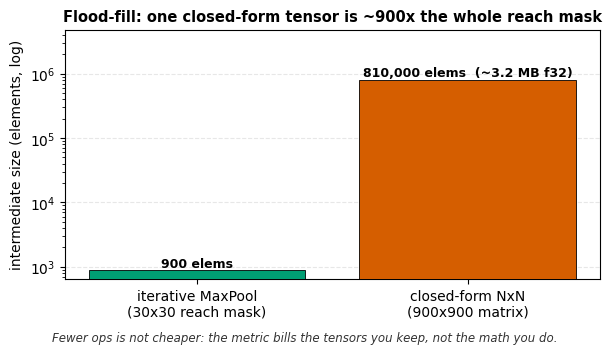

In [25]:
import pandas as pd, matplotlib.pyplot as plt

# --- the three dead ends, priced against the scorer above ---
dead = [
    ("INT4 / sub-byte packing", "fewer param bytes",
     "params count elements, not bytes, so packing the same weights changes nothing"),
    ("sparse_initializer", "tiny params (only nnz count)",
     "it materializes back to dense at runtime, so memory rises; on a real ~80%-zero table, cost went 27,671 -> 28,496"),
    ("closed-form flood-fill (one NxN MatMul)", "one cheap matrix op",
     "the 900x900 reachability tensor (~3.2 MB) dominates the bill; the iterative MaxPool version scores far better"),
]
dfx = pd.DataFrame(dead, columns=["tempting idea", "the hope", "what it actually does"])
try:
    from IPython.display import display
    display(dfx.style.hide(axis="index")
            .set_properties(**{"font-size": "13px"})
            .set_table_styles([{"selector": "th", "props": [("background-color", "#333"), ("font-size", "13px"),
                ("color", "white"), ("text-align", "left")]}])
            .set_properties(**{"text-align": "left", "vertical-align": "top", "background-color": "#fdecea"})
            .set_properties(subset=["what it actually does"], **{"max-width": "380px", "white-space": "normal"})
            .set_caption('Three "free lunches" that raised the bill. Measured with the exact scorer from Part 1.'))
except Exception:
    print(dfx.to_string(index=False))

# --- the flood-fill trap, drawn: the dominant intermediate tensor ---
fig, ax = plt.subplots(figsize=(6.2, 3.4))
elems = [900, 810000]                       # 30x30 reach mask  vs  900x900 reachability matrix
labels = ["iterative MaxPool\n(30x30 reach mask)", "closed-form NxN\n(900x900 matrix)"]
bars = ax.bar(labels, elems, color=["#009E73", "#D55E00"], edgecolor="black", lw=0.6, zorder=3)
ax.set_yscale("log")
ax.set_title('Flood-fill: one closed-form tensor is ~900x the whole reach mask', fontsize=10.5, fontweight="bold")
ax.set_ylabel("intermediate size (elements, log)")
ax.grid(axis="y", ls="--", alpha=0.3, zorder=0)
for b, e in zip(bars, elems):
    ax.annotate(f"{e:,} elems" + ("  (~3.2 MB f32)" if e > 1000 else ""),
                (b.get_x() + b.get_width()/2, e), ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_ylim(top=elems[1]*6)
fig.text(0.5, -0.02, 'Fewer ops is not cheaper: the metric bills the tensors you keep, not the math you do.',
         ha="center", fontsize=8.5, style="italic", color="#333")
fig.tight_layout(); plt.show()

<a id="takeaways"></a>
## Takeaways

I lost a submission to one file. Here are the five lessons so you don't:

1. **Match the server runtime.** Your local `onnxruntime` is probably newer; cost and `ERROR`s differ. Pin it.
2. **Score with the exact formula** (`params + memory`, intermediates summed, I/O free) — not `onnx-tool`'s estimate.
3. **Validate all 400 files before submitting** on a *real* input. One bad file zeroes everything.
4. **Don't ban ops from hearsay** — probe them. `TopK` works.
5. The whole optimisation game is **removing/shrinking intermediate tensors** (bool/uint8/fp16, Pad-at-the-end, no dead constants — the server doesn't fold them for you).

None of this is hindsight-proof by itself — but the winners' write-ups bear all five out in production form. [The next section](#winners) maps each one to their pipelines.

### Credits
- Competition & generators: **Michael D. Moffitt** and the host team; the open **ARC-GEN** generator set.
- Surgery techniques that inspired Part 1's dtype intuition: **@seddiktrk** (Graph Surgeon), **@qinghchen** (dtype-tail / zero-pad / row-gather).
- The community's public blends, which made the cost model measurable.

<a id="winners"></a>
## What the winners did — and what it confirms

The top teams have started publishing their write-ups. As of mid-July 2026, five are up and four have real detail (one is still an empty draft). Reading those four, what struck me is how much of each pipeline was *plumbing* — the same tools this kit walks through. What follows is what I took from them, with credit where each idea belongs.


In [26]:
import pandas as pd
from IPython.display import display

# The section's promised map, literal: five kit lessons x four write-ups (verbatim hooks, credited above).
_rows = {
 "Pin the server runtime":      {"6th": "an ORT 1.24.4 run inside the gate"},
 "Score with the exact formula":{"1st": "measured +0.5 vs +0.05 per task", "7th": "rulebook: how the score works, the hard limits"},
 "Validate all 400 first":      {"6th": "full gate + 1000 fresh samples + singleton submissions", "10th": "differential submissions to isolate failures"},
 "Probe ops, don't trust folklore": {"10th": "shipped a 226-operand Einsum in production"},
 "The game is kept intermediates":  {"1st": "rewrites beat polish 10:1", "10th": "T001 memory 0; T017 cost 60 -> 10"},
}
_cols = ["1st", "6th", "7th", "10th"]
_df = pd.DataFrame([{c: r.get(c, "") for c in _cols} for r in _rows.values()], index=list(_rows.keys()))
def _mstyle(v):
    return "background-color:#e2f4e0;text-align:left" if v else "background-color:#f5f5f5"
try:
    display(_df.style.map(_mstyle)
            .set_properties(**{"font-size": "13px"})
            .set_table_styles([{"selector": "th", "props": [("background-color", "#333"), ("font-size", "13px"),
                ("color", "white"), ("text-align", "left")]}])
            .set_caption("Each kit lesson and where a top write-up runs it in production. Note the "
                         "op-ban row — by the end nobody was arguing with the probe. Numbers verbatim from the "
                         "linked write-ups; wording condensed to fit the cells."))
except Exception:
    print(_df.to_string())

,1st,6th,7th,10th
Pin the server runtime,,an ORT 1.24.4 run inside the gate,,
Score with the exact formula,measured +0.5 vs +0.05 per task,,"rulebook: how the score works, the hard limits",
Validate all 400 first,,full gate + 1000 fresh samples + singleton submissions,,differential submissions to isolate failures
"Probe ops, don't trust folklore",,,,shipped a 226-operand Einsum in production
The game is kept intermediates,rewrites beat polish 10:1,,,T001 memory 0; T017 cost 60 -> 10


**Rewrites beat polish, ten to one.** Team Kaggle Agent — Chris Deotte, Giba, Jiwei Liu, Max Jeblick and Eduardo Rocha de Andrade — report in their [1st-place write-up](https://www.kaggle.com/competitions/neurogolf-2026/writeups/1st-place-kaggle-agent) that "architectural rewrites averaged +0.5 boost per task" while optimising existing graphs averaged only +0.05. Part 1 is the reason why: the metric bills the tensors a graph keeps, and MACs are free — so a different architecture changes the bill, while polishing the same graph only trims it.

**Validation was load-bearing.** The [6th-place team (Claudex)](https://www.kaggle.com/competitions/neurogolf-2026/writeups/6th-place-solution-claudex) promoted a candidate only after it passed a gate that included the ONNX checker, shape inference, an ORT 1.24.4 run, exact public examples, *fresh ARC-GEN validation on 1000 generated samples*, and the file-size limit — plus "singleton submissions to identify failures before submitting a full batch" for risky files. That is Part 2 and the silent-zero gate, run as a production pipeline.

**The output tensor is free — write straight to it.** Yiheng Wang's solo-gold [10th-place write-up](https://www.kaggle.com/competitions/neurogolf-2026/writeups/draft-10th-place-solution) shows T001 solved by a single 226-operand Einsum writing directly to the output: cost 98, of which memory is **zero**. And where a graph carried state, he recomputed it instead (T017: cost 60 → 10). Those are the two ends of Part 1's price list — intermediates are billed, `input`/`output` and compute are not.

**When a batch fails, bisect it.** The same write-up describes locating bad tasks by *differential submissions* — splitting a changed set into groups and comparing score deltas until the failing file is isolated. That is the manual version of what `validate_dir` tries to save you from, and the right tool once a failure only reproduces server-side.

**Give the agent the rulebook.** In the [7th-place thread](https://www.kaggle.com/competitions/neurogolf-2026/writeups/7th-place-solution-slow-and-steady), M Sato describes `NEUROGOLF_PROMPT.md` as "the rulebook and strategy. It explains how the score works, the hard limits" — the method they set ChatGPT to follow, alongside a knowledge base that grew to 68 rules. Scoring rules and hard limits as machine-readable inputs: that is what an exact local scorer and a validator are for, whether the reader is a person or an agent.

None of this retroactively makes the kit a winning strategy — the winners' edge was architecture search at scale. But wherever a write-up shows its pipeline, a mechanical verifier is under it. That part you can fork today.

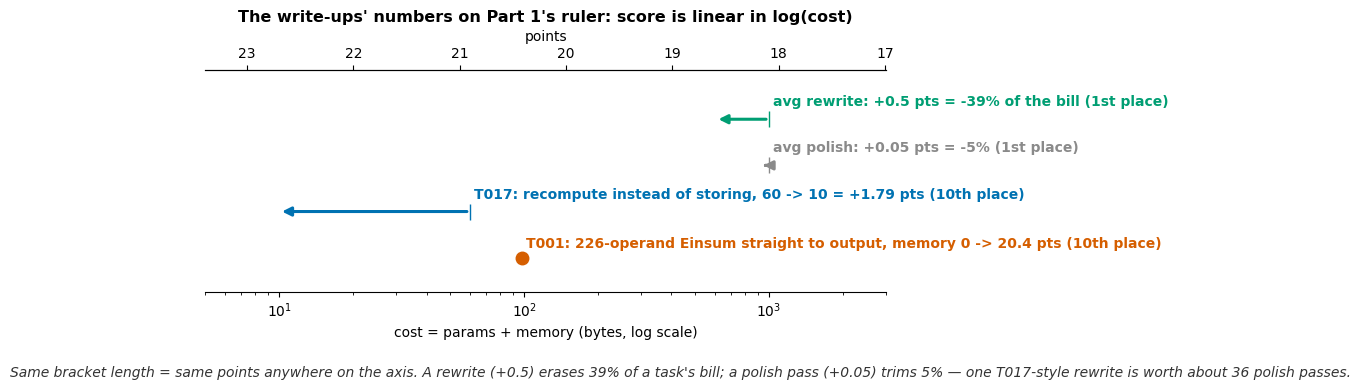

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

# The winners' headline numbers on Part 1's ruler. All figures verbatim from the write-ups credited above.
BLUE, VERM, GREEN, GREY, INK = "#0072B2", "#D55E00", "#009E73", "#8a8a8a", "#1b2a41"

fig, ax = plt.subplots(figsize=(9.8, 3.6))
ax.set_xscale("log"); ax.set_xlim(5, 3000); ax.set_ylim(0.3, 3.9)
ax.set_yticks([]); ax.set_xlabel("cost = params + memory (bytes, log scale)")
sec = ax.secondary_xaxis("top", functions=(lambda c: 25 - np.log(np.maximum(c, 1e-9)), lambda p: np.exp(25 - p)))
sec.set_xticks([17, 18, 19, 20, 21, 22, 23]); sec.set_xticklabels(["17", "18", "19", "20", "21", "22", "23"])
sec.set_xlabel("points")
for sp in ("left", "right"): ax.spines[sp].set_visible(False)

def bracket(y, x0, x1, color, label):
    ax.add_patch(FancyArrowPatch((x0, y), (x1, y), arrowstyle="-|>", mutation_scale=13, color=color, lw=2.2))
    ax.plot([x0], [y], marker="|", ms=11, color=color)
    ax.text(x0 * 1.04, y + 0.22, label, fontsize=10, color=color, fontweight="bold")

bracket(3.1, 1000, 1000 * np.exp(-0.5), GREEN, "avg rewrite: +0.5 pts = -39% of the bill (1st place)")
bracket(2.35, 1000, 1000 * np.exp(-0.05), GREY, "avg polish: +0.05 pts = -5% (1st place)")
bracket(1.6, 60, 10, BLUE, "T017: recompute instead of storing, 60 -> 10 = +1.79 pts (10th place)")
ax.plot([98], [0.85], marker="o", ms=9, color=VERM)
ax.text(102, 1.02, "T001: 226-operand Einsum straight to output, memory 0 -> 20.4 pts (10th place)",
        fontsize=10, color=VERM, fontweight="bold")

ax.set_title("The write-ups' numbers on Part 1's ruler: score is linear in log(cost)", fontsize=11.5, fontweight="bold")
fig.text(0.5, -0.06, "Same bracket length = same points anywhere on the axis. A rewrite (+0.5) erases 39% of a task's bill; "
         "a polish pass (+0.05) trims 5% \u2014 one T017-style rewrite is worth about 36 polish passes.",
         ha="center", fontsize=10, style="italic", color="#333")
fig.tight_layout(); plt.show()

<a id="reading"></a>
## What to read next

None of this kit would exist without the host's generators and the community's public work. These are the ones I learned the most from.

**How the winners did it** *(post-competition write-ups)*

- [1st place — Kaggle Agent](https://www.kaggle.com/competitions/neurogolf-2026/writeups/1st-place-kaggle-agent) by Chris Deotte, Giba, Jiwei Liu, Max Jeblick, Eduardo Rocha de Andrade: agents plus a shared dashboard — the write-up behind the rewrites-beat-polish numbers above.
- [6th place — Claudex](https://www.kaggle.com/competitions/neurogolf-2026/writeups/6th-place-solution-claudex) by Binh, Phạm Ngọc Thiên Ân, An, Bửu Phạm Quốc and Hai Nguyen Thien: the clearest published validation gate, and their list of core optimisation tricks.
- [7th place — Slow and Steady](https://www.kaggle.com/competitions/neurogolf-2026/writeups/7th-place-solution-slow-and-steady) by yash bhaskar, Paritosh Kumar Tripathi, M Sato, cg, David Austin: the rulebook-driven agent workflow (the detail is in the thread comments for now).
- [10th place](https://www.kaggle.com/competitions/neurogolf-2026/writeups/draft-10th-place-solution) by Yiheng Wang (solo gold): the most detailed pipeline write-up so far — three-file task units, transactional promotion, differential submissions.

**Start here**

- [The 2026 NeuroGolf Championship](https://www.kaggle.com/code/mmoffitt/the-2026-neurogolf-championship) by Michael D. Moffitt (the competition host): the official starter, the scoring rules, and your first valid submission. Read this first.

**Understand the tasks**

- [All Task Description Analysis](https://www.kaggle.com/code/karnakbaevarthur/all-task-description-analysis) by Karnakbayev Artur: a guided tour of all 400 tasks — the best way to build intuition for what you're solving.

**Cost-reduction techniques**

- [ONNX Rewrites + Hand-Built Solvers](https://www.kaggle.com/code/octaviograu/6154-71-onnx-rewrites-hand-built-solvers) by Octavi Grau: hand-crafted ONNX for specific tasks — the clearest public example of the rewrites-beat-polish lesson the winners confirmed.

- [NeuroGolf 2026: Graph Surgeon](https://www.kaggle.com/code/seddiktrk/neurogolf-2026-graph-surgeon) by seddik turki: the canonical reference on cutting parameters and intermediates out of a graph without breaking it.
- [Surgical ONNX: Precision Parameter Reduction](https://www.kaggle.com/code/seddiktrk/surgical-onnx-precision-parameter-reduction) by seddik turki: a deeper, more precise follow-up on shaving cost node by node.
- [Convolution Series - Part 3](https://www.kaggle.com/code/massimilianoghiotto/convolution-series-part-3) by MassimilianoGhiotto: expressing grid transforms as cheap convolutions — a recurring trick for small, exact solvers.

**Six more, if you want to go deeper.** Several carry a leaderboard number in their title; the board has moved a long way since they were written, so read them for the method, not the number.

*Another starter, and task studies*

- [NeuroGolf 2026: Improved Starter Notebook](https://www.kaggle.com/code/yash9439/neurogolf-2026-improved-starter-notebook) by yash bhaskar: a cleaner on-ramp than the bare starter while the competition ran; the official starter plus this kit now cover what it added.
- [Logic Decoder](https://www.kaggle.com/code/karnakbaevarthur/logic-decoder) by Karnakbayev Artur: reverse-engineers the transformation logic, so you can target the right ONNX ops.
- [EDA + Best Public Score](https://www.kaggle.com/code/massimilianoghiotto/eda-111-best-public-score) by MassimilianoGhiotto: ties task patterns to where the score actually comes from.

*Hand-built solvers to study*

- [ARC Nano-Engine](https://www.kaggle.com/code/svanikkolli/arc-nano-engine) by Svanik Kolli: a tiny engine that reasons over ARC grids — great for minimal-op solver design.
- [Rule-Based ONNX Solver](https://www.kaggle.com/code/imaadmahmood/neurogolf-2026-rule-based-onnx-solver) by Imaad Mahmood: a readable pipeline that turns task rules directly into small graphs.

*A bundle to practice on*

- [Audited ONNX Overrides](https://www.kaggle.com/code/kojimar/audited-neurogolf-onnx-overrides) by islet: a high-scoring, *audited* override set from the live leaderboard — the best real bundle to attach and run `validate_dir` and Part 4 on.

That is the whole survival kit: an exact local scorer, a pre-submit validator, and a couple of myths put to rest. A public score is only yours once it survives the server runtime — so fork this, point `validate_dir` at any bundle (late submissions still score), then go read the write-ups; the plumbing will already be familiar. Tell me in the comments which op *you* almost banned by mistake.

Written by Georgy Mamarin. The live version and any updates are on Kaggle at [kaggle.com/georgymamarin](https://www.kaggle.com/georgymamarin).